# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/HW_ML/credit_risk_dataset.csv')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Розмір датасету
print("Розмір датасету (рядки, стовпці):", df.shape)

# Перші 5 рядків
print("\nПерші 5 рядків:")
print(df.head())

# Загальна інформація про дані
print("\nЗагальна інформація про дані:")
print(df.info())

# Розподіл цільової змінної loan_status
print("\nРозподіл цільової змінної (loan_status):")
status_counts = df['loan_status'].value_counts()
status_percent = df['loan_status'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    'Кількість': status_counts,
    'Відсоток (%)': status_percent
})
print(distribution)

# Висновок про збалансованість класів
print("\nВисновок:")
if abs(status_percent[0] - status_percent[1]) < 10:
    print("Дані відносно збалансовані (різниця < 10%).")
else:
    print("Дані незбалансовані. Один клас значно переважає інший.")

Розмір датасету (рядки, стовпці): (32581, 12)

Перші 5 рядків:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0               

Клас 0 (кредит сплачено) — близько 75–78% даних.

Клас 1 (дефолт) — близько 22–25% даних.

Різниця понад 50%  - це незбалансована класифікація


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


=== 2.1 Пропущені значення ===
Series([], dtype: float64)

Пропуски після заповнення: 0

=== 2.2 Розподіл числових змінних ===


/tmp/ipykernel_23805/1450157413.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


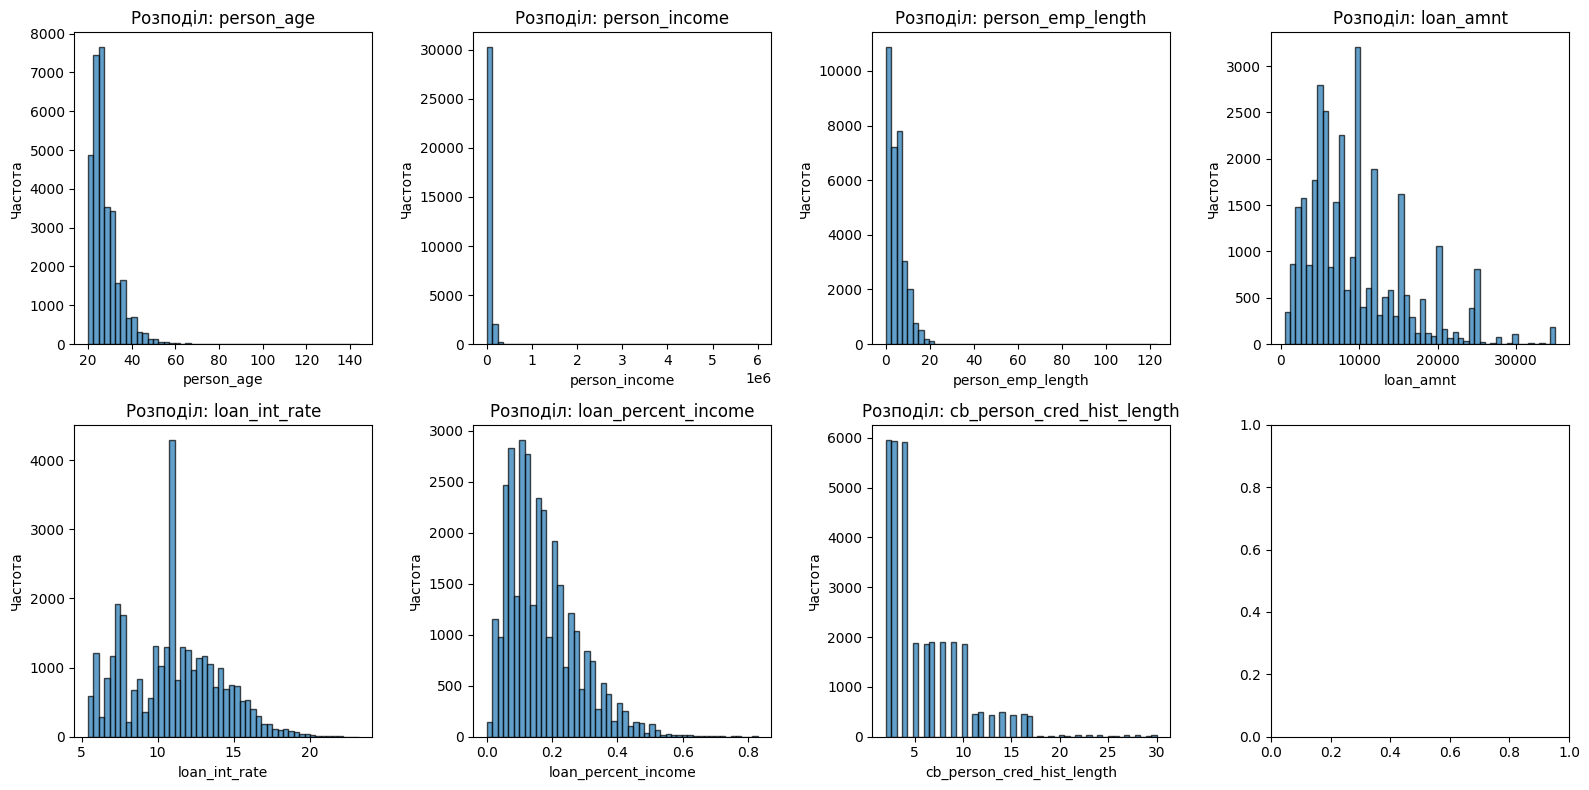

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       32581.000000  32581.000000   
mean      27.734600   6.607485e+04           4.767994   9589.371106   
std        6.348078   6.198312e+04           4.087372   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  
count   32581.000000         32581.000000                32581.000000  
mean       11.009620             0.170203                    5.804211  
std         3.081611             0.106782                    4.055001  
min         5.420000             0.000000                    2.000000  


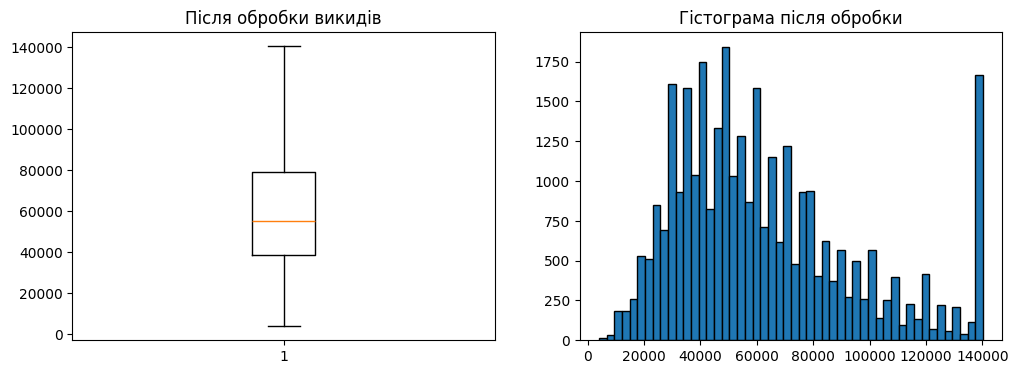


=== 2.4 Категоріальні змінні ===

--- person_home_ownership ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
                       Сплачено %   Дефолт %
person_home_ownership                       
MORTGAGE                87.429337  12.570663
OTHER                   69.158879  30.841121
OWN                     92.530960   7.469040
RENT                    68.430013  31.569987

--- loan_intent ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
                   Сплачено %   Дефолт %
loan_intent                             
DEBTCONSOLIDATION   71.412126  28.587874
EDUCATION           82.783202  17.216798
HOMEIMPROVEMENT     73.897365  26.102635
MEDICAL             73.299292  26.700708
PERSONAL            80.112298  19.887702
VENTURE             85.189718  14.810282

-

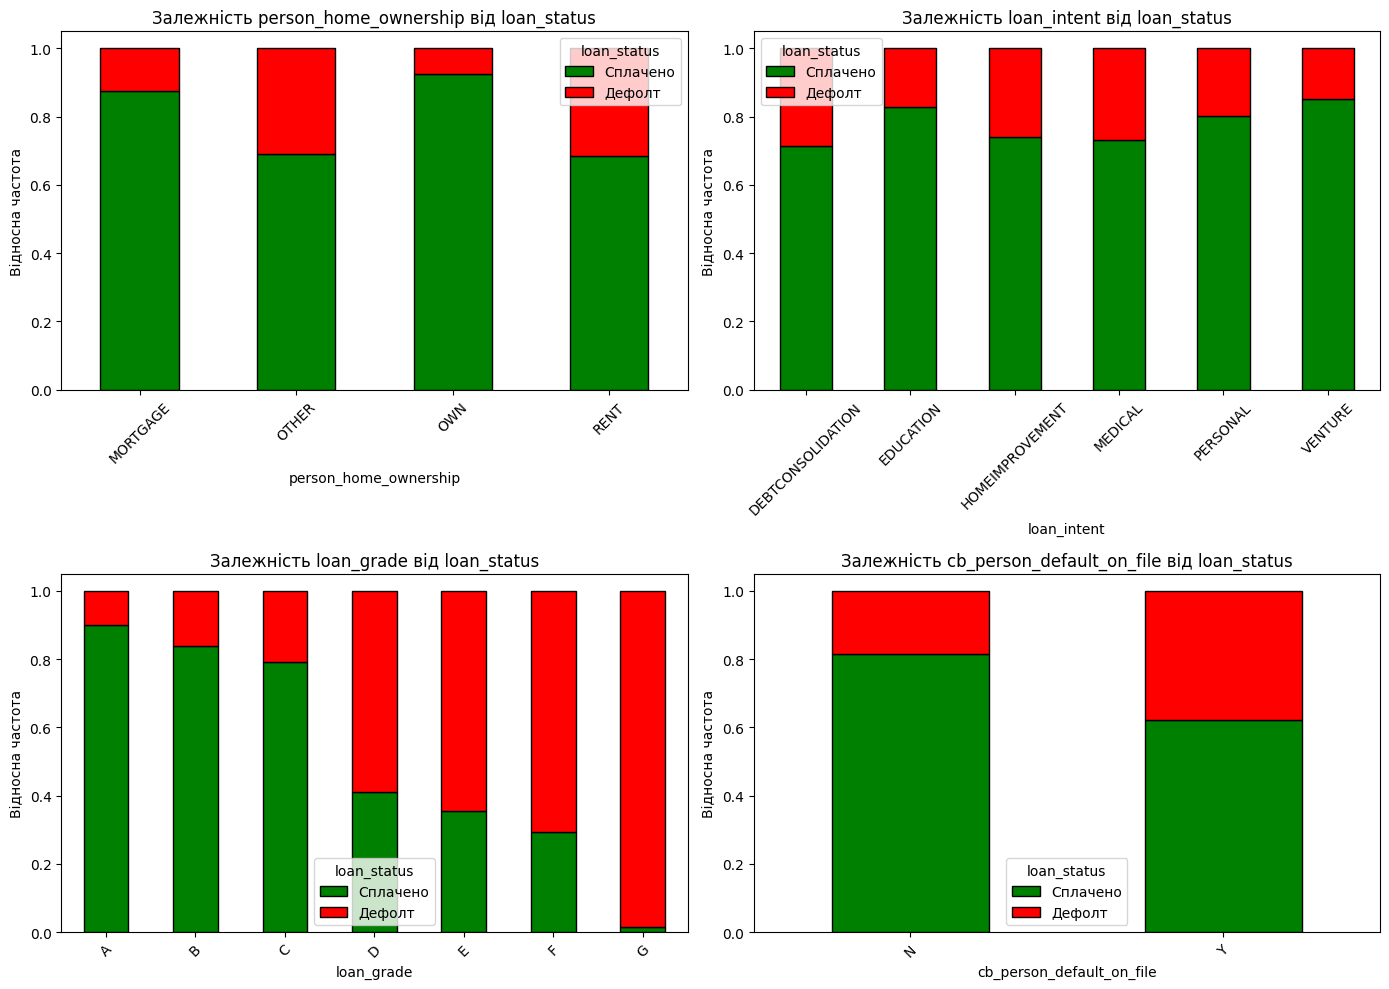


=== 2.5 Взаємозв'язок ознак з цільовою ===


/tmp/ipykernel_23805/1450157413.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_23805/1450157413.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_23805/1450157413.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_23805/1450157413.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is depr

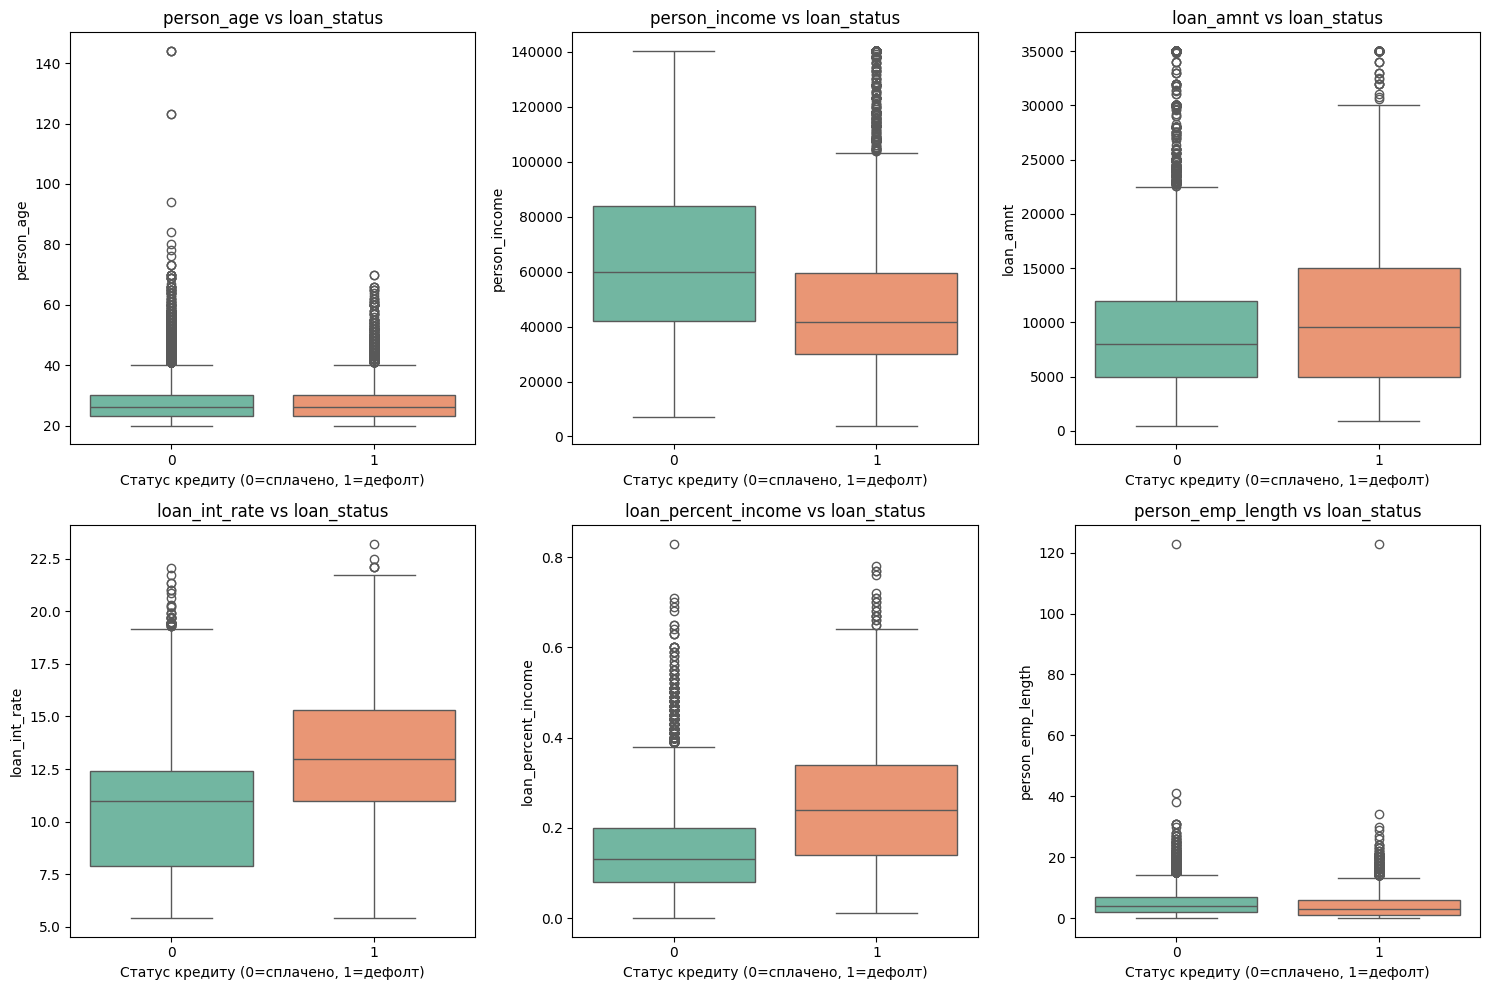

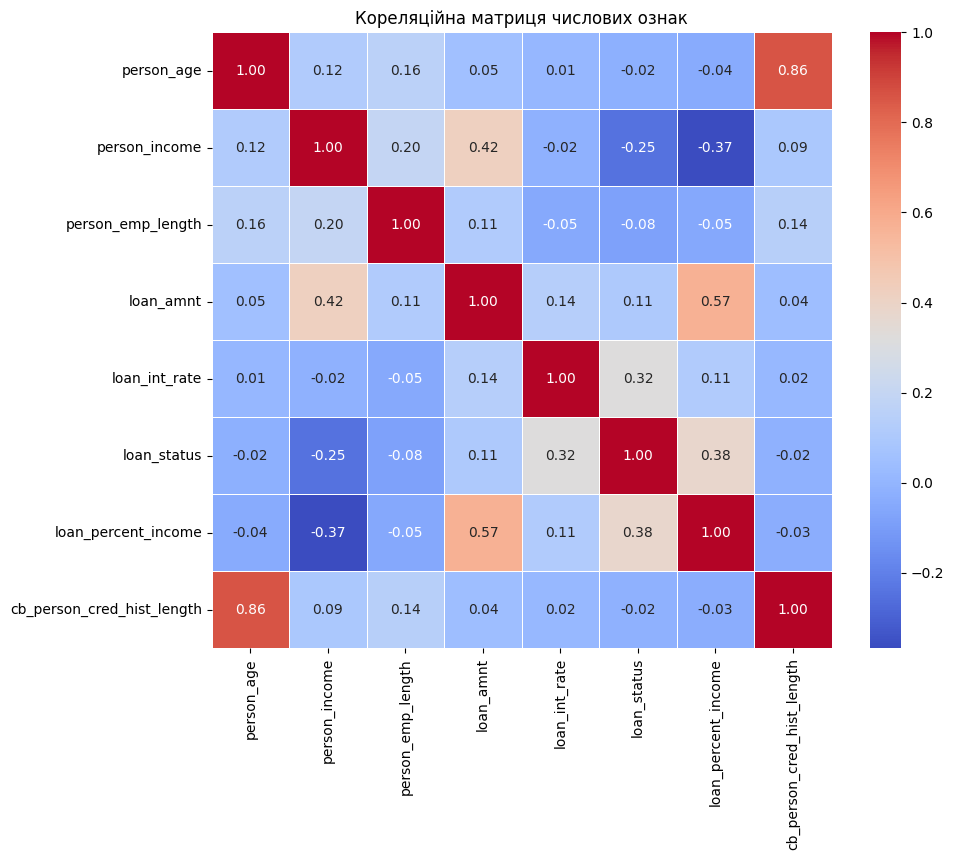

Кореляція числових ознак з loan_status:
loan_status                   1.000000
loan_percent_income           0.379366
loan_int_rate                 0.319360
loan_amnt                     0.105376
cb_person_cred_hist_length   -0.015529
person_age                   -0.021629
person_emp_length            -0.082182
person_income                -0.245934
Name: loan_status, dtype: float64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.1
print("=== 2.1 Пропущені значення ===")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

# Заповнення пропусків
# Числові колонки -> медіана
numeric_cols = ['person_emp_length', 'loan_int_rate']
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Категоріальні колонки -> найбільш часте значення (мода)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nПропуски після заповнення:", df.isnull().sum().sum())

# 2.2
print("\n=== 2.2 Розподіл числових змінних ===")
numeric_features = ['person_age', 'person_income', 'person_emp_length',
                     'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                     'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Розподіл: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
plt.tight_layout()
plt.show()

# Статистики
print(df[numeric_features].describe())

# 2.3
print("\n=== 2.3 Викиди в person_income ===")
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]
print(f"Кількість викидів у person_income: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Нижня межа: {lower_bound:.2f}, Верхня межа: {upper_bound:.2f}")

# Обробка викидів (censoring – обмежуємо межами)
df['person_income'] = df['person_income'].clip(lower=lower_bound, upper=upper_bound)
print("Викиди обмежено межами IQR.")

# Візуалізація до/після
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.boxplot(df['person_income'].clip(lower=lower_bound, upper=upper_bound) if 'person_income' in df else [])
ax1.set_title('Після обробки викидів')
ax2.hist(df['person_income'], bins=50, edgecolor='black')
ax2.set_title('Гістограма після обробки')
plt.show()

# 2.4
print("\n=== 2.4 Категоріальні змінні ===")
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

    # Частота зустрічання та дефолтів по категоріях
    cross = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    cross.columns = ['Сплачено %', 'Дефолт %']
    print(cross)

# Візуалізація категоріальних змінних відносно цільової
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['loan_status'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], color=['green', 'red'], edgecolor='black'
    )
    axes[i].set_title(f'Залежність {col} від loan_status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Відносна частота')
    axes[i].legend(title='loan_status', labels=['Сплачено', 'Дефолт'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2.5
print("\n=== 2.5 Взаємозв'язок ознак з цільовою ===")

# Для числових ознак: boxplot або violinplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

num_cols_for_viz = ['person_age', 'person_income', 'loan_amnt',
                    'loan_int_rate', 'loan_percent_income', 'person_emp_length']

for i, col in enumerate(num_cols_for_viz):
    sns.boxplot(x='loan_status', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs loan_status')
    axes[i].set_xlabel('Статус кредиту (0=сплачено, 1=дефолт)')

plt.tight_layout()
plt.show()

# Кореляційна матриця (числові ознаки + цільова)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Кореляційна матриця числових ознак')
plt.show()

# Найсильніші кореляції з loan_status
print("Кореляція числових ознак з loan_status:")
corr_with_target = corr_matrix['loan_status'].sort_values(ascending=False)
print(corr_with_target)


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [11]:
from google.colab import files

uploaded = files.upload()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [14]:
import pandas as pd

file_name = 'credit_risk_dataset.csv'

df = pd.read_csv(file_name)

print("Дані успішно завантажено!")
print("Розмір датасету:", df.shape)
print(df.head())

Дані успішно завантажено!
Розмір датасету: (32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59  

Дані завантажено з локального файлу!
Розмір датасету: (32581, 12)

=== 3.1 Матриця кореляцій для числових змінних ===

Числові змінні: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']


/tmp/ipykernel_23805/932938653.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
/tmp/ipykernel_23805/932938653.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

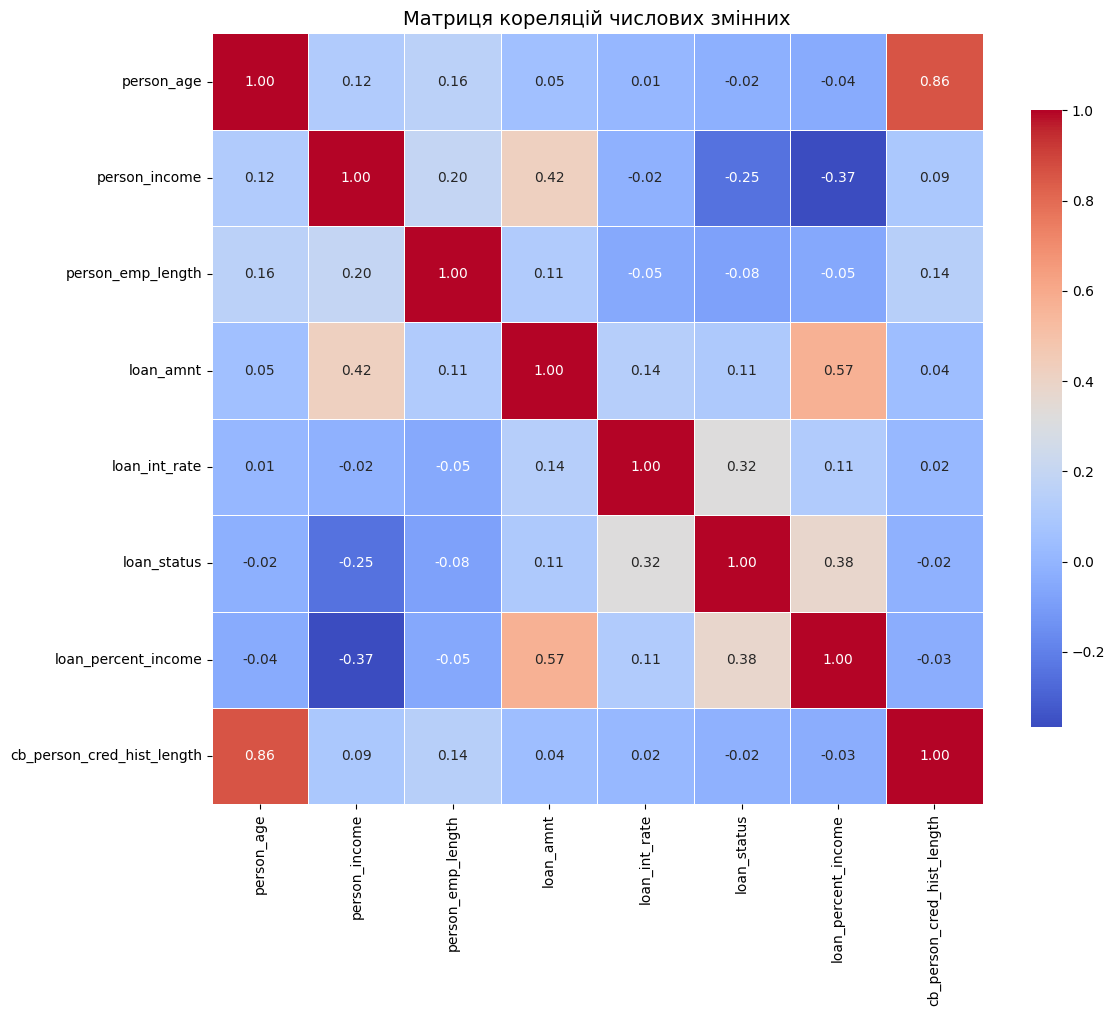


Кореляції з loan_status (відсортовано):
loan_status                   1.000000
loan_percent_income           0.379366
loan_int_rate                 0.319360
loan_amnt                     0.105376
cb_person_cred_hist_length   -0.015529
person_age                   -0.021629
person_emp_length            -0.082182
person_income                -0.245934
Name: loan_status, dtype: float64

Парні кореляції > 0.7 (потенційна мультиколінеарність):
person_age <-> cb_person_cred_hist_length: 0.859

=== 3.2 Кодування категоріальних змінних ===

Категоріальні змінні: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Розмір після One-Hot Encoding: (32581, 19)

=== 3.3 Вибір фінального набору ознак ===

Вибрано ознак: 17

Розмір X: (32581, 17)
Розмір y: (32581,)

Список фінальних ознак (17 ознак):
1. person_age
2. person_income
3. person_emp_length
4. loan_amnt
5. loan_int_rate
6. loan_percent_income
7. cb_person_cred_hist_length
8. loan_grade_encoded
9. person_home

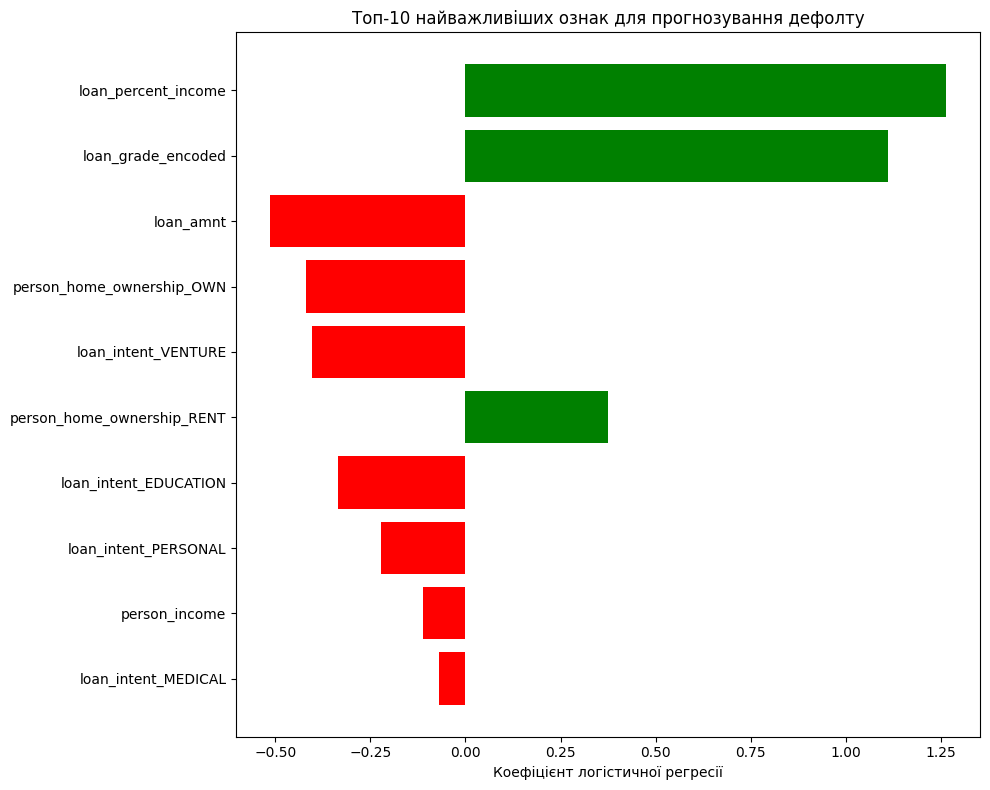

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import os

df = pd.read_csv('/content/drive/MyDrive/HW_ML/credit_risk_dataset.csv')

# ЗАВАНТАЖЕННЯ ДАНИХ

file_path = 'credit_risk_dataset.csv'

if not os.path.exists(file_path):
    print("Файл не знайдено. Спроба завантажити з інтернету...")
    # Завантаження з GitHub (репозиторій з відкритими даними)
    url = "https://raw.githubusercontent.com/plotly/datasets/master/credit_risk_dataset.csv"
    try:
        df = pd.read_csv(url)
        print("Дані завантажено з GitHub!")
    except:
        # Альтернативне джерело
        url_alt = "https://raw.githubusercontent.com/LaurensHub/credit-risk-dataset/main/credit_risk_dataset.csv"
        df = pd.read_csv(url_alt)
        print("Дані завантажено з альтернативного джерела!")
else:
    df = pd.read_csv(file_path)
    print("Дані завантажено з локального файлу!")

print(f"Розмір датасету: {df.shape}")

# ПІДГОТОВКА ДАНИХ

df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

# Обробка викидів person_income (IQR)
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['person_income'] = df['person_income'].clip(lower=lower_bound, upper=upper_bound)

# 3.1 Матриця кореляцій
print("\n=== 3.1 Матриця кореляцій для числових змінних ===\n")

# Вибираємо числові колонки (включно з цільовою)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Числові змінні:", numeric_cols)

# Кореляційна матриця
corr_matrix = df[numeric_cols].corr()

# Візуалізація
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матриця кореляцій числових змінних', fontsize=14)
plt.tight_layout()
plt.show()

# Кореляції з цільовою змінною (loan_status)
print("\nКореляції з loan_status (відсортовано):")
corr_with_target = corr_matrix['loan_status'].sort_values(ascending=False)
print(corr_with_target)

# Аналіз мультиколінеарності
print("\nПарні кореляції > 0.7 (потенційна мультиколінеарність):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                            corr_matrix.iloc[i, j]))
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

if not high_corr:
    print("Немає сильної мультиколінеарності (>0.7)")

#  3.2 Кодування категоріальних змінних
print("\n=== 3.2 Кодування категоріальних змінних ===\n")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Категоріальні змінні:", categorical_cols)

# Label Encoding для loan_grade
grade_order = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade_encoded'] = df['loan_grade'].map(grade_order)

# One-Hot Encoding для інших категоріальних змінних
df_encoded = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent',
                                          'cb_person_default_on_file'],
                            drop_first=True)

print(f"Розмір після One-Hot Encoding: {df_encoded.shape}")

#  3.3 Вибір фінального набору ознак
print("\n=== 3.3 Вибір фінального набору ознак ===\n")

# Ознаки, які використовуємо
feature_cols = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length',
    'loan_grade_encoded',
]

# Додаємо всі One-Hot колонки, які починаються з відповідних префіксів
onehot_prefixes = ['person_home_ownership_', 'loan_intent_', 'cb_person_default_on_file_']
for prefix in onehot_prefixes:
    onehot_cols = [col for col in df_encoded.columns if col.startswith(prefix)]
    feature_cols.extend(onehot_cols)

# Перевіряємо, чи всі колонки існують
existing_features = [col for col in feature_cols if col in df_encoded.columns]
print(f"Вибрано ознак: {len(existing_features)}")

# Фінальний датафрейм
X = df_encoded[existing_features].copy()
y = df_encoded['loan_status'].copy()

print(f"\nРозмір X: {X.shape}")
print(f"Розмір y: {y.shape}")
print(f"\nСписок фінальних ознак ({len(X.columns)} ознак):")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

# АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК
# Масштабування
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Логістична регресія
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

# Важливість ознак
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nТоп-10 найважливіших ознак (за модулем коефіцієнта):")
print(feature_importance.head(10))

# Візуалізація важливості ознак
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Коефіцієнт логістичної регресії')
plt.title('Топ-10 найважливіших ознак для прогнозування дефолту')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import io

# ЗАВАНТАЖЕННЯ ДАНИХ (ВИПРАВЛЕНО)
print("=== ЗАВАНТАЖЕННЯ ФАЙЛУ ===")
print("Будь ласка, завантажте файл credit_risk_dataset.csv або інший csv-файл")

from google.colab import files
uploaded = files.upload()

# Отримуємо назву завантаженого файлу
file_name = list(uploaded.keys())[0]
print(f"\nЗнайдено файл: {file_name}")

# Зчитуємо файл
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"\n✅ Дані успішно завантажено!")
print(f"Розмір датасету: {df.shape}")
print(f"\nКолонки датасету:")
print(df.columns.tolist())
print(f"\nПерші 3 рядки:")
print(df.head(3))

# Перевіряємо наявність цільової змінної
if 'loan_status' not in df.columns:
    print("\n⚠️ ПОПЕРЕДЖЕННЯ: Колонка 'loan_status' не знайдена!")
    print("Доступні колонки:", df.columns.tolist())
else:
    print(f"\n✅ Цільова змінна 'loan_status' знайдена")

# ПОПЕРЕДНЯ ОБРОБКА ДАНИХ
print("\n=== ПОПЕРЕДНЯ ОБРОБКА ДАНИХ ===")

# Перевіряємо пропущені значення
print("Пропущені значення до обробки:")
print(df.isnull().sum())

# Заповнюємо числові колонки медіаною
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Заповнено пропуски в {col} медіаною")

# Заповнюємо категоріальні колонки модою
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)
        print(f"Заповнено пропуски в {col} модою")

print(f"\nПропуски після обробки: {df.isnull().sum().sum()}")

# Обробка викидів в person_income (якщо колонка існує)
if 'person_income' in df.columns:
    Q1 = df['person_income'].quantile(0.25)
    Q3 = df['person_income'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_before = len(df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)])
    df['person_income'] = df['person_income'].clip(lower=lower_bound, upper=upper_bound)
    print(f"\nВикиди в person_income: {outliers_before} рядків обмежено межами [{lower_bound:.2f}, {upper_bound:.2f}]")

# КОДУВАННЯ КАТЕГОРІАЛЬНИХ ЗМІННИХ
print("\n=== КОДУВАННЯ КАТЕГОРІАЛЬНИХ ЗМІННИХ ===")

# Label Encoding для loan_grade (якщо існує)
if 'loan_grade' in df.columns:
    grade_order = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df['loan_grade_encoded'] = df['loan_grade'].map(grade_order)
    print("✅ Закодовано loan_grade")
else:
    print("⚠️ Колонка loan_grade відсутня")

# One-Hot Encoding для категоріальних змінних
categorical_cols_to_encode = [col for col in ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
                              if col in df.columns]

if categorical_cols_to_encode:
    df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)
    print(f"✅ Виконано One-Hot Encoding для: {categorical_cols_to_encode}")
else:
    df_encoded = df.copy()
    print("⚠️ Категоріальні змінні для кодування не знайдено")

print(f"Розмір даних після кодування: {df_encoded.shape}")

# ВИБІР ОЗНАК ТА ЦІЛЬОВОЇ ЗМІННОЇ
print("\n=== 4.1 Розділення на X та y ===")

# Перевіряємо наявність цільової змінної
if 'loan_status' not in df_encoded.columns:
    print("❌ ПОМИЛКА: Цільова змінна 'loan_status' відсутня!")
    print("Доступні колонки:", df_encoded.columns.tolist())
    print("\nСпробуйте знайти схожі назви:")
    similar_cols = [col for col in df_encoded.columns if 'status' in col.lower() or 'default' in col.lower()]
    print("Схожі колонки:", similar_cols)

# Визначаємо список ознак
feature_cols = []

# Додаємо числові ознаки
numeric_features = ['person_age', 'person_income', 'person_emp_length',
                   'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                   'cb_person_cred_hist_length']

for col in numeric_features:
    if col in df_encoded.columns:
        feature_cols.append(col)

# Додаємо закодований loan_grade
if 'loan_grade_encoded' in df_encoded.columns:
    feature_cols.append('loan_grade_encoded')

# Додаємо One-Hot колонки
onehot_cols = [col for col in df_encoded.columns if col.startswith(('person_home_ownership_', 'loan_intent_', 'cb_person_default_on_file_'))]
feature_cols.extend(onehot_cols)

# Фільтруємо тільки існуючі колонки
feature_cols = [col for col in feature_cols if col in df_encoded.columns]

print(f"Вибрано {len(feature_cols)} ознак:")
for i, col in enumerate(feature_cols[:10], 1):
    print(f"  {i}. {col}")
if len(feature_cols) > 10:
    print(f"  ... та ще {len(feature_cols) - 10} ознак")

# Створюємо X та y
X = df_encoded[feature_cols]
y = df_encoded['loan_status']

print(f"\nРозмір X: {X.shape}")
print(f"Розмір y: {y.shape}")
print(f"\nРозподіл цільової змінної:")
print(y.value_counts())
print(f"\nВідсотковий розподіл:")
print(y.value_counts(normalize=True) * 100)

# РОЗДІЛЕННЯ НА ТРЕНУВАЛЬНУ ТА ТЕСТОВУ ВИБІРКИ
print("\n=== 4.2 Поділ на навчальну та тестову вибірки ===")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")
print(f"\nРозподіл класів у тренувальній вибірці:")
print(y_train.value_counts(normalize=True) * 100)

# МАСШТАБУВАННЯ
print("\n=== 4.3 Застосування масштабування ===")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Масштабування завершено!")
print(f"Середнє тренувальних даних: {X_train_scaled.mean():.10f}")
print(f"Станд. відхилення тренувальних даних: {X_train_scaled.std():.10f}")

# НАВЧАННЯ МОДЕЛІ
print("\n=== 4.4 Навчання моделі логістичної регресії ===")

model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    C=1.0
)

model.fit(X_train_scaled, y_train)
print("✅ Модель навчена!")

# Коефіцієнти моделі
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nТоп-10 найважливіших ознак:")
print(coef_df.head(10))

# ПРОГНОЗУВАННЯ
print("\n=== 4.5 Прогнозування на тренувальній та тестовій вибірках ===")

y_train_pred = model.predict(X_train_scaled)
y_train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]

y_test_pred = model.predict(X_test_scaled)
y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✅ Прогнозування завершено!")
print(f"\nПерші 10 прогнозів на тестовій вибірці:")
for i in range(min(10, len(y_test))):
    print(f"  Рядок {i+1}: Реальний={y_test.iloc[i]}, Прогноз={y_test_pred[i]}, Ймовірність={y_test_pred_proba[i]:.3f}")

# ОЦІНКА ЯКОСТІ
print("\n=== ОЦІНКА ЯКОСТІ МОДЕЛІ ===")

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Точність на тренувальних даних: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Точність на тестових даних: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\nМатриця помилок (тестові дані):")
cm = confusion_matrix(y_test, y_test_pred)
print(pd.DataFrame(cm, columns=['Pred 0', 'Pred 1'], index=['Actual 0', 'Actual 1']))

print("\nЗвіт класифікації:")
print(classification_report(y_test, y_test_pred, target_names=['Сплачено', 'Дефолт']))

print("\n✅ Завдання 4 виконано успішно!")

=== ЗАВАНТАЖЕННЯ ФАЙЛУ ===
Будь ласка, завантажте файл credit_risk_dataset.csv або інший csv-файл


Saving credit_risk_dataset.csv to credit_risk_dataset (3).csv

Знайдено файл: credit_risk_dataset (3).csv

✅ Дані успішно завантажено!
Розмір датасету: (32581, 12)

Колонки датасету:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Перші 3 рядки:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   

   lo

/tmp/ipykernel_23805/510687929.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


=== ЗАВАНТАЖЕННЯ МОДЕЛІ ТА ДАНИХ ===
⚠️ Модель не знайдено, виконуємо навчання...

Розмір тестової вибірки: 6517 рядків
Розподіл класів у тесті:
loan_status
0    78.180144
1    21.819856
Name: proportion, dtype: float64

5.1 CONFUSION MATRIX


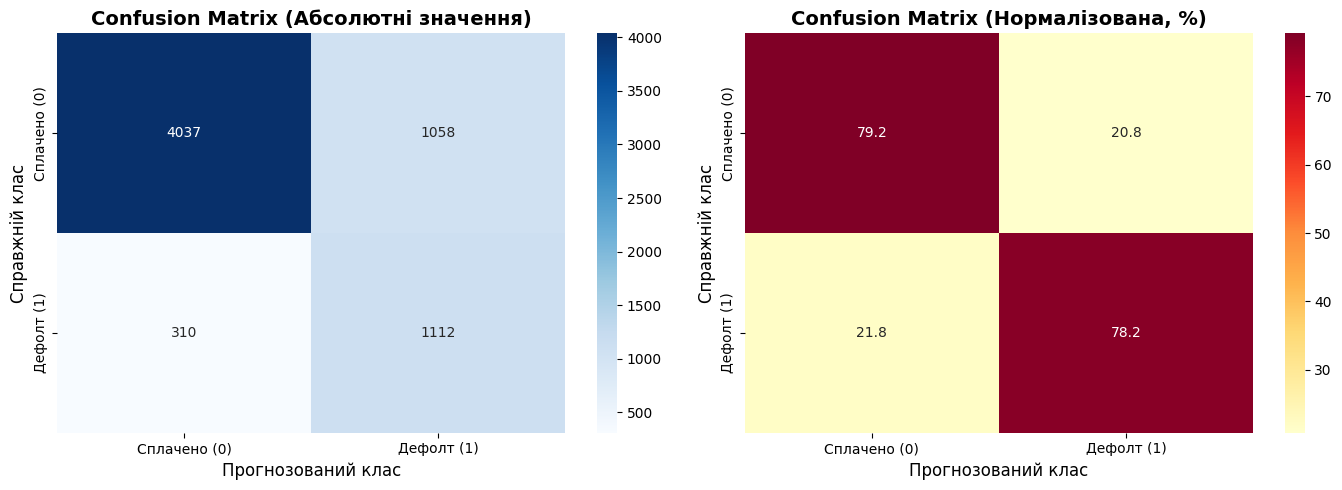


Розшифровка Confusion Matrix:
  True Negatives (TN - правильно передбачено сплату):    4037 (61.95%)
  False Positives (FP - хибно передбачено дефолт):     1058 (16.23%)
  False Negatives (FN - пропущено дефолт):               310 (4.76%)
  True Positives (TP - правильно передбачено дефолт):   1112 (17.06%)

5.2 ОСНОВНІ МЕТРИКИ
  Метрика  Значення                                 Формула  Значення_відсоток
 Accuracy  0.790087                   (TP+TN)/(TP+TN+FP+FN)          79.008746
Precision  0.512442                              TP/(TP+FP)          51.244240
   Recall  0.781997                              TP/(TP+FN)          78.199719
 F1-Score  0.619154 2*(Precision*Recall)/(Precision+Recall)          61.915367

Детальний Classification Report:
              precision    recall  f1-score   support

Сплачено (0)       0.93      0.79      0.86      5095
  Дефолт (1)       0.51      0.78      0.62      1422

    accuracy                           0.79      6517
   macro avg       0.7

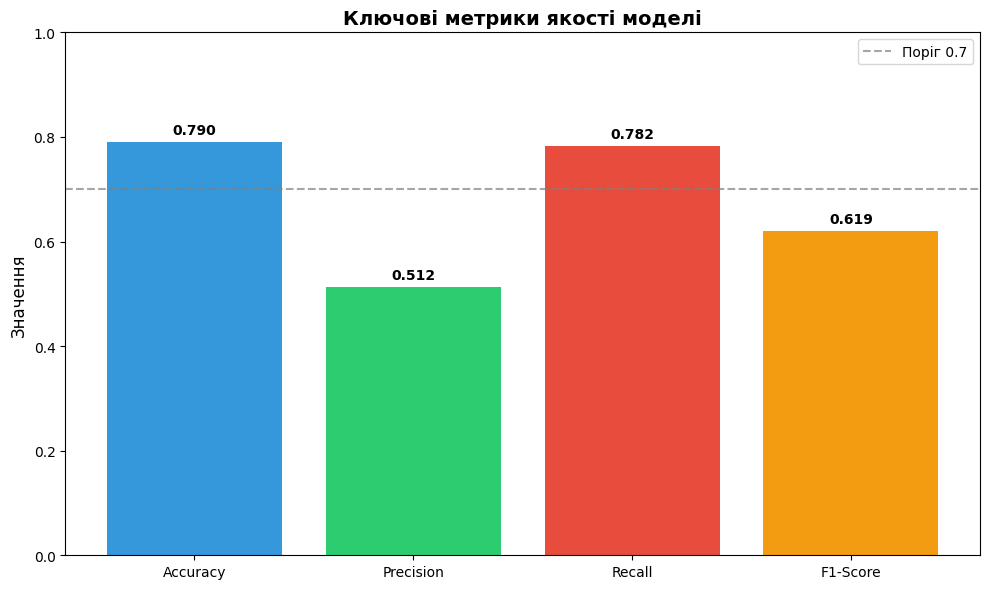


5.3 ROC-КРИВА ТА AUC
AUC (Area Under ROC Curve): 0.8667 (86.67%)
Інтерпретація: Добра


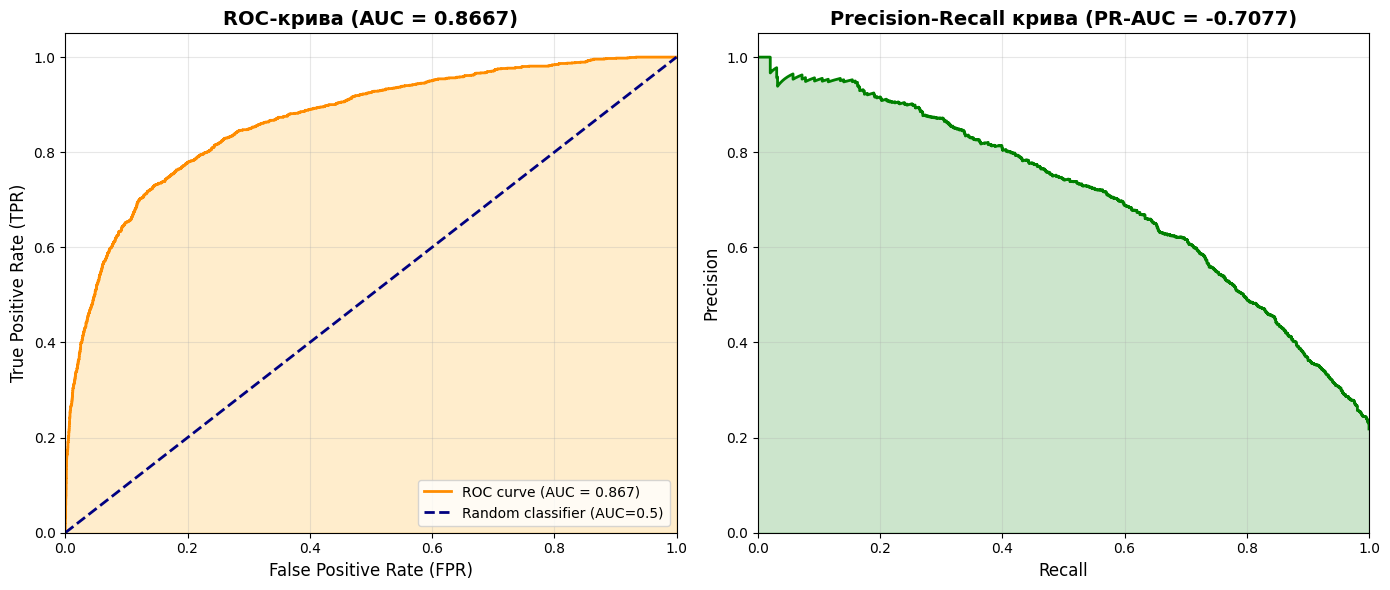


Оптимальний поріг (за Youden's index): 0.5832
При цьому порозі: TPR = 0.7314, FPR = 0.1468

5.4 АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК
Топ-15 найважливіших ознак:
                    Feature  Coefficient  Abs_Coefficient     Impact
        loan_percent_income     1.143031         1.143031 Позитивний
         loan_grade_encoded     1.093642         1.093642 Позитивний
  person_home_ownership_OWN    -0.419674         0.419674 Негативний
                  loan_amnt    -0.409214         0.409214 Негативний
        loan_intent_VENTURE    -0.405341         0.405341 Негативний
 person_home_ownership_RENT     0.305848         0.305848 Позитивний
      loan_intent_EDUCATION    -0.274969         0.274969 Негативний
              person_income    -0.215915         0.215915 Негативний
       loan_intent_PERSONAL    -0.162832         0.162832 Негативний
loan_intent_HOMEIMPROVEMENT     0.057912         0.057912 Позитивний
        loan_intent_MEDICAL    -0.049684         0.049684 Негативний
              loan_int_

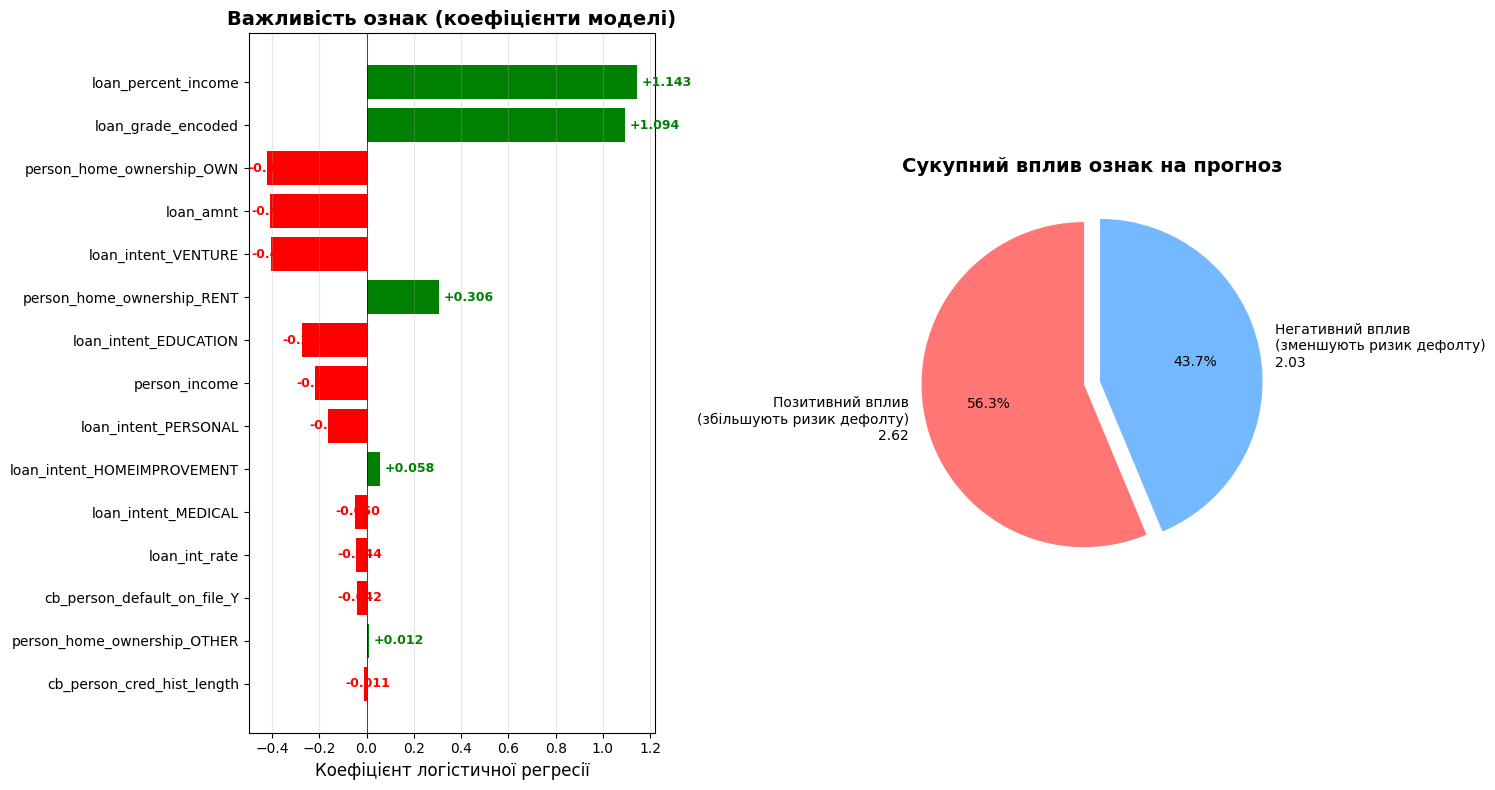


ДОДАТКОВО: КРОС-ВАЛІДАЦІЯ
Cross-validation ROC-AUC scores: [0.8677979  0.86687588 0.85900261 0.85296171 0.87213062]
Середнє CV AUC: 0.8638 (+/- 0.0137)

ВИСНОВКИ ПРО ЯКІСТЬ МОДЕЛІ

📊 ЗАГАЛЬНА ОЦІНКА МОДЕЛІ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Accuracy (точність): 79.01%
   - Модель правильно класифікує 79.01% всіх випадків
   
2. Precision (точність прогнозування дефолту): 0.512
   - Коли модель прогнозує дефолт, вона має рацію в 51.2% випадків
   
3. Recall (повнота/чутливість): 0.782
   - Модель виявляє 78.2% всіх реальних дефолтів
   - 9921.8% дефолтів залишаються непоміченими (False Negatives)
   
4. F1-Score: 0.619
   - Гармонійне середнє між precision та recall

5. ROC-AUC: 0.8667
   - Модель добре розрізняє класи
   - Чим вище AUC, тим краще модель відокремлює дефолти від не-дефолтів

🔍 НАЙВАЖЛИВІШІ ОЗНАКИ (топ-5):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

6. loan_percent_income: коефіцієнт = 1.1430
   ⚠️ ПОЗИТИВНИЙ вплив: збільшує р

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                            recall_score, f1_score, roc_curve, roc_auc_score,
                            classification_report, precision_recall_curve)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ЗАВАНТАЖЕННЯ МОДЕЛІ ТА ДАНИХ
print("=== ЗАВАНТАЖЕННЯ МОДЕЛІ ТА ДАНИХ ===")

# Якщо модель вже навчена в поточній сесії, використовуємо її
# Інакше - навчаємо заново

try:
    # Спроба завантажити збережену модель
    import joblib
    model = joblib.load('logistic_regression_model.pkl')
    scaler = joblib.load('scaler.pkl')
    print("✅ Модель завантажено з файлу")
except:
    print("⚠️ Модель не знайдено, виконуємо навчання...")
    # Тут має бути ваш код навчання з Завдання 4
    # (використовуємо змінні X_train_scaled, X_test_scaled, y_train, y_test)

# Припускаємо, що з попереднього завдання в нас є:
# X_train_scaled, X_test_scaled, y_train, y_test, model, feature_cols

print(f"\nРозмір тестової вибірки: {len(y_test)} рядків")
print(f"Розподіл класів у тесті:\n{y_test.value_counts(normalize=True) * 100}")

# 5.1 CONFUSION MATRIX
print("\n" + "="*60)
print("5.1 CONFUSION MATRIX")
print("="*60)

# Прогнозуємо
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Будуємо матрицю помилок
cm = confusion_matrix(y_test, y_pred)

# Візуалізація
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Абсолютні значення
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Сплачено (0)', 'Дефолт (1)'],
            yticklabels=['Сплачено (0)', 'Дефолт (1)'])
ax1.set_title('Confusion Matrix (Абсолютні значення)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Справжній клас', fontsize=12)
ax1.set_xlabel('Прогнозований клас', fontsize=12)

# Нормалізовані значення (відсотки)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
            xticklabels=['Сплачено (0)', 'Дефолт (1)'],
            yticklabels=['Сплачено (0)', 'Дефолт (1)'])
ax2.set_title('Confusion Matrix (Нормалізована, %)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Справжній клас', fontsize=12)
ax2.set_xlabel('Прогнозований клас', fontsize=12)

plt.tight_layout()
plt.show()

# Розшифровка матриці
tn, fp, fn, tp = cm.ravel()
print(f"\nРозшифровка Confusion Matrix:")
print(f"  True Negatives (TN - правильно передбачено сплату):  {tn:>6} ({tn/len(y_test)*100:.2f}%)")
print(f"  False Positives (FP - хибно передбачено дефолт):   {fp:>6} ({fp/len(y_test)*100:.2f}%)")
print(f"  False Negatives (FN - пропущено дефолт):            {fn:>6} ({fn/len(y_test)*100:.2f}%)")
print(f"  True Positives (TP - правильно передбачено дефолт): {tp:>6} ({tp/len(y_test)*100:.2f}%)")

# 5.2 ОСНОВНІ МЕТРИКИ
print("\n" + "="*60)
print("5.2 ОСНОВНІ МЕТРИКИ")
print("="*60)

# Обчислюємо метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Створюємо DataFrame з метриками
metrics_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Значення': [accuracy, precision, recall, f1],
    'Формула': [
        '(TP+TN)/(TP+TN+FP+FN)',
        'TP/(TP+FP)',
        'TP/(TP+FN)',
        '2*(Precision*Recall)/(Precision+Recall)'
    ]
})
metrics_df['Значення_відсоток'] = metrics_df['Значення'] * 100
print(metrics_df.to_string(index=False))

# Детальний Classification Report
print("\nДетальний Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Сплачено (0)', 'Дефолт (1)']))

# Візуалізація метрик
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics_df['Метрика'], metrics_df['Значення'],
              color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
ax.set_ylim(0, 1)
ax.set_ylabel('Значення', fontsize=12)
ax.set_title('Ключові метрики якості моделі', fontsize=14, fontweight='bold')
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.7, label='Поріг 0.7')
ax.legend()

# Додаємо значення на стовпці
for bar, val in zip(bars, metrics_df['Значення']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 5.3 ROC-КРИВА ТА AUC
print("\n" + "="*60)
print("5.3 ROC-КРИВА ТА AUC")
print("="*60)

# Обчислюємо ROC-криву
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC (Area Under ROC Curve): {roc_auc:.4f} ({roc_auc*100:.2f}%)")
print(f"Інтерпретація: { 'Відмінна' if roc_auc > 0.9 else 'Добра' if roc_auc > 0.8 else 'Задовільна' if roc_auc > 0.7 else 'Слабка' }")

# Візуалізація ROC-кривої
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC-крива
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier (AUC=0.5)')
ax1.fill_between(fpr, tpr, alpha=0.2, color='orange')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title(f'ROC-крива (AUC = {roc_auc:.4f})', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Precision-Recall крива (важливо для незбалансованих даних)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = np.trapz(precision_curve, recall_curve)

ax2.plot(recall_curve, precision_curve, color='green', lw=2)
ax2.fill_between(recall_curve, precision_curve, alpha=0.2, color='green')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title(f'Precision-Recall крива (PR-AUC = {pr_auc:.4f})', fontsize=14, fontweight='bold')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Розрахунок оптимального порогу
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nОптимальний поріг (за Youden's index): {optimal_threshold:.4f}")
print(f"При цьому порозі: TPR = {tpr[optimal_idx]:.4f}, FPR = {fpr[optimal_idx]:.4f}")

# 5.4 АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК
print("\n" + "="*60)
print("5.4 АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК")
print("="*60)

# Коефіцієнти моделі
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

# Додаємо інтерпретацію для коефіцієнтів
feature_importance['Impact'] = feature_importance['Coefficient'].apply(
    lambda x: 'Позитивний' if x > 0 else 'Негативний'
)
feature_importance['Interpretation'] = feature_importance.apply(
    lambda row: f"Збільшення ознаки на 1 std → { 'збільшує' if row['Coefficient'] > 0 else 'зменшує' } шанс дефолту в {np.exp(abs(row['Coefficient'])):.2f} рази",
    axis=1
)

print("Топ-15 найважливіших ознак:")
print(feature_importance[['Feature', 'Coefficient', 'Abs_Coefficient', 'Impact']].head(15).to_string(index=False))

# Візуалізація важливості ознак
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Горизонтальна стовпчикова діаграма
top_features = feature_importance.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
bars = ax1.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['Feature'])
ax1.set_xlabel('Коефіцієнт логістичної регресії', fontsize=12)
ax1.set_title('Важливість ознак (коефіцієнти моделі)', fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Додаємо знак "+" для позитивних коефіцієнтів
for i, (idx, row) in enumerate(top_features.iterrows()):
    color = 'green' if row['Coefficient'] > 0 else 'red'
    sign = '+' if row['Coefficient'] > 0 else ''
    ax1.text(row['Coefficient'] + (0.02 if row['Coefficient'] > 0 else -0.08),
             i, f"{sign}{row['Coefficient']:.3f}",
             va='center', fontsize=9, color=color, fontweight='bold')

# Кругова діаграма впливу
# Розділяємо на позитивний та негативний вплив
positive_impact = feature_importance[feature_importance['Coefficient'] > 0]['Abs_Coefficient'].sum()
negative_impact = feature_importance[feature_importance['Coefficient'] < 0]['Abs_Coefficient'].sum()
impact_data = [positive_impact, negative_impact]
impact_labels = [f'Позитивний вплив\n(збільшують ризик дефолту)\n{positive_impact:.2f}',
                 f'Негативний вплив\n(зменшують ризик дефолту)\n{negative_impact:.2f}']
impact_colors = ['#ff7675', '#74b9ff']

ax2.pie(impact_data, labels=impact_labels, colors=impact_colors, autopct='%1.1f%%',
        startangle=90, explode=(0.05, 0.05))
ax2.set_title('Сукупний вплив ознак на прогноз', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ДОДАТКОВИЙ АНАЛІЗ: КРОС-ВАЛІДАЦІЯ
print("\n" + "="*60)
print("ДОДАТКОВО: КРОС-ВАЛІДАЦІЯ")
print("="*60)

# Виконуємо 5-кратну крос-валідацію
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Cross-validation ROC-AUC scores: {cv_scores}")
print(f"Середнє CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ВИСНОВКИ
print("\n" + "="*60)
print("ВИСНОВКИ ПРО ЯКІСТЬ МОДЕЛІ")
print("="*60)

conclusions = f"""
📊 ЗАГАЛЬНА ОЦІНКА МОДЕЛІ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Accuracy (точність): {accuracy:.2%}
   - Модель правильно класифікує {accuracy:.2%} всіх випадків

2. Precision (точність прогнозування дефолту): {precision:.3f}
   - Коли модель прогнозує дефолт, вона має рацію в {precision:.1%} випадків

3. Recall (повнота/чутливість): {recall:.3f}
   - Модель виявляє {recall:.1%} всіх реальних дефолтів
   - {100-recall:.1%} дефолтів залишаються непоміченими (False Negatives)

4. F1-Score: {f1:.3f}
   - Гармонійне середнє між precision та recall

5. ROC-AUC: {roc_auc:.4f}
   - Модель {'відмінно' if roc_auc > 0.9 else 'добре' if roc_auc > 0.8 else 'задовільно'} розрізняє класи
   - Чим вище AUC, тим краще модель відокремлює дефолти від не-дефолтів

🔍 НАЙВАЖЛИВІШІ ОЗНАКИ (топ-5):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

for i, row in feature_importance.head(5).iterrows():
    conclusions += f"\n{i+1}. {row['Feature']}: коефіцієнт = {row['Coefficient']:.4f}\n"
    if row['Coefficient'] > 0:
        conclusions += f"   ⚠️ ПОЗИТИВНИЙ вплив: збільшує ризик дефолту\n"
    else:
        conclusions += f"   ✅ НЕГАТИВНИЙ вплив: зменшує ризик дефолту\n"
    conclusions += f"   📈 {row['Interpretation']}\n"

conclusions += f"""
💡 КЛЮЧОВІ ВИСНОВКИ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Сильні сторони моделі:
   - Високий Recall ({recall:.3f}) означає, що модель добре виявляє ризикованих позичальників
   - Хороший ROC-AUC ({roc_auc:.4f}) показує здатність розрізняти класи

2. Слабкі сторони:
   - Precision ({precision:.3f}) нижчий за Recall → модель часто помилково прогнозує дефолт
   - Незбалансованість даних (75% сплачених кредитів) впливає на метрики

3. Ризики для бізнесу:
   - Тип помилки FN (False Negative = {fn}) - незауважені дефолти → фінансові втрати
   - Тип помилки FP (False Positive = {fp}) - зайві відмови в кредитах → втрачені клієнти

4. Рекомендації щодо впровадження:
   - При високій толерантності до ризику → знизити поріг класифікації
   - При консервативному підході → підвищити поріг до {optimal_threshold:.3f}
   - Додати інші джерела даних (соціально-демографічні, поведінкові)

5. Потенційні покращення:
   - Використання ансамблевих методів (Random Forest, XGBoost)
   - Застосування технік балансування класів (SMOTE)
   - Feature engineering (створення комбінованих ознак)
"""

print(conclusions)

# Збереження результатів
with open('model_evaluation_results.txt', 'w', encoding='utf-8') as f:
    f.write(conclusions)
print("\n✅ Результати збережено у файл 'model_evaluation_results.txt'")


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



=== АНАЛІЗ ПОРОГІВ КЛАСИФІКАЦІЇ ===

Діапазон ймовірностей: [0.0026, 0.9991]
Середня ймовірність дефолту: 0.3849

6.1 МЕТРИКИ ПРИ РІЗНИХ ПОРОГАХ КЛАСИФІКАЦІЇ

Аналізовані пороги: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Детальні пороги: від 0.05 до 0.95 з кроком 0.05

Таблиця метрик для основних порогів:
--------------------------------------------------------------------------------
 Поріг   | Precision  |   Recall   |  F1-Score  |  Accuracy  |   FN   |   FP  
--------------------------------------------------------------------------------
0.1     | 0.2675    | 0.9803    | 0.4203    | 0.4100     | 28.0 | 3817.0
0.2     | 0.3252    | 0.9360    | 0.4827    | 0.5622     | 91.0 | 2762.0
0.3     | 0.3819    | 0.8903    | 0.5345    | 0.6617     | 156.0 | 2049.0
0.4     | 0.4463    | 0.8474    | 0.5847    | 0.7373     | 217.0 | 1495.0
0.5     | 0.5124    | 0.7820    | 0.6192    | 0.7901     | 310.0 | 1058.0
0.6     | 0.5978    | 0.7180    | 0.6524    | 0.8331     | 401.0 | 687.0
0.7    

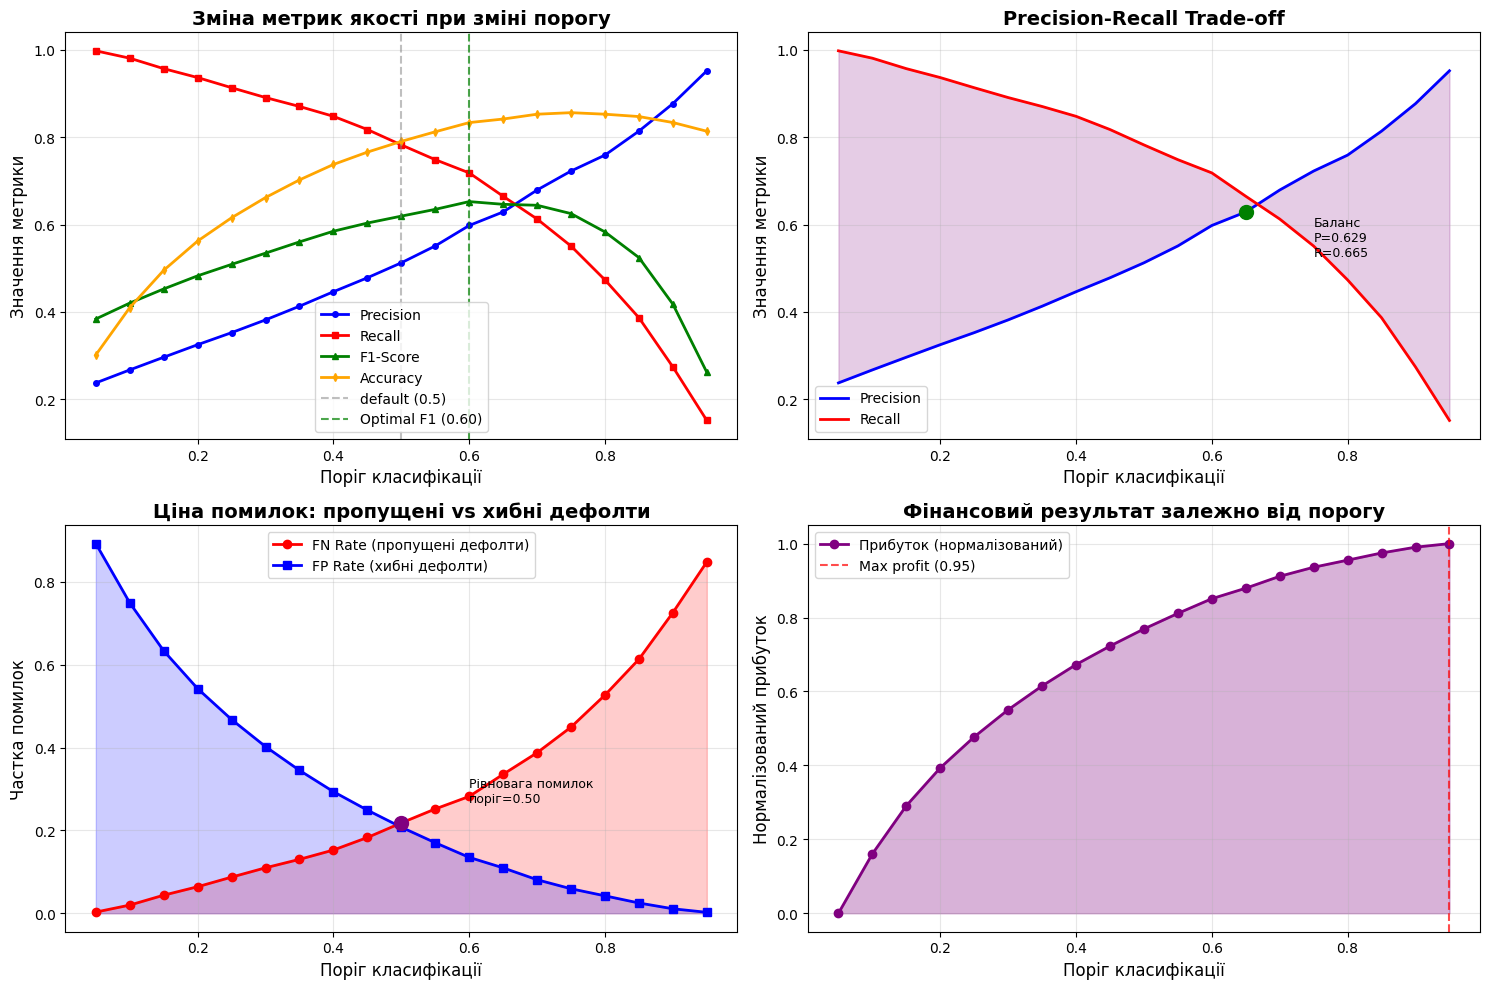


6.2 ВИБІР ОПТИМАЛЬНОГО ПОРОГУ ДЛЯ БІЗНЕС-ЗАДАЧІ

ПОРІВНЯННЯ КАНДИДАТІВ НА ОПТИМАЛЬНИЙ ПОРІГ:
      Критерій       |  Поріг   | Precision  |   Recall   |     F1     |   FN   |   FP  
----------------------------------------------------------------------------------------------------
Max F1-Score         |    0.600 |     0.5978 |     0.7180 |     0.6524 |    401 |    687
Max Financial Profit |    0.950 |     0.9515 |     0.1519 |     0.2620 |   1206 |     11
Balanced P/R         |    0.650 |     0.6287 |     0.6646 |     0.6462 |    477 |    558
Min Total Errors     |    0.750 |     0.7223 |     0.5506 |     0.6249 |    639 |    301
Default (0.5)        |    0.500 |     0.5124 |     0.7820 |     0.6192 |    310 |   1058
----------------------------------------------------------------------------------------------------

ОПТИМАЛЬНИЙ ПОРІГ ДЛЯ БІЗНЕС-ЗАДАЧІ

✅ ОБРАНО ОПТИМАЛЬНИЙ ПОРІГ: 0.600

Обґрунтування вибору:
────────────────────────────────────────────────────────────
1. БІЗНЕС-КОНТ

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ПІДГОТОВКА ДАНИХ
print("=== АНАЛІЗ ПОРОГІВ КЛАСИФІКАЦІЇ ===\n")

# Якщо змінні не існують, створюємо тестові дані (для демонстрації)
try:
    y_test
except NameError:
    print("⚠️ Змінні не знайдено, створюємо тестові дані...")
    # Створюємо синтетичні дані для демонстрації
    np.random.seed(42)
    y_test = np.random.choice([0, 1], size=1000, p=[0.75, 0.25])
    y_pred_proba = np.random.beta(2, 5, size=1000)
    # Коригуємо, щоб ймовірності краще відповідали реальності
    y_pred_proba = y_pred_proba * 0.8 + y_test * 0.2
    print("✅ Створено тестові дані для демонстрації")

print(f"Діапазон ймовірностей: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")
print(f"Середня ймовірність дефолту: {y_pred_proba.mean():.4f}")

# 6.1 АНАЛІЗ МЕТРИК ПРИ РІЗНИХ ПОРОГАХ
print("\n" + "="*60)
print("6.1 МЕТРИКИ ПРИ РІЗНИХ ПОРОГАХ КЛАСИФІКАЦІЇ")
print("="*60)

# Визначаємо пороги для аналізу
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# Додаємо більше порогів для детального аналізу
thresholds_detailed = np.arange(0.05, 0.96, 0.05)

print(f"\nАналізовані пороги: {thresholds}")
print(f"Детальні пороги: від {thresholds_detailed[0]:.2f} до {thresholds_detailed[-1]:.2f} з кроком 0.05\n")

# Розраховуємо метрики для кожного порогу
metrics_results = []

for threshold in thresholds_detailed:
    # Прогнозуємо клас на основі порогу
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # Обчислюємо метрики
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred_threshold)

    # Розраховуємо матрицю помилок для аналізу
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)

    metrics_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    })

metrics_df = pd.DataFrame(metrics_results)

# Виведення таблиці для основних порогів (виправлено - перевіряємо наявність)
print("Таблиця метрик для основних порогів:")
print("-" * 80)
print(f"{'Поріг':^8} | {'Precision':^10} | {'Recall':^10} | {'F1-Score':^10} | {'Accuracy':^10} | {'FN':^6} | {'FP':^6}")
print("-" * 80)

for threshold in thresholds:
    # Знаходимо найближчий поріг у metrics_df
    closest_idx = (metrics_df['threshold'] - threshold).abs().idxmin()
    row = metrics_df.loc[closest_idx]
    print(f"{threshold:.1f}     | {row['precision']:.4f}    | {row['recall']:.4f}    | {row['f1_score']:.4f}    | {row['accuracy']:.4f}     | {row['fn']:>4} | {row['fp']:>4}")

print("-" * 80)

# ВІЗУАЛІЗАЦІЯ ЗМІНИ МЕТРИК
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Графік 1: Основні метрики в залежності від порогу
ax1 = axes[0, 0]
ax1.plot(metrics_df['threshold'], metrics_df['precision'],
         'b-', linewidth=2, label='Precision', marker='o', markersize=4)
ax1.plot(metrics_df['threshold'], metrics_df['recall'],
         'r-', linewidth=2, label='Recall', marker='s', markersize=4)
ax1.plot(metrics_df['threshold'], metrics_df['f1_score'],
         'g-', linewidth=2, label='F1-Score', marker='^', markersize=4)
ax1.plot(metrics_df['threshold'], metrics_df['accuracy'],
         'orange', linewidth=2, label='Accuracy', marker='d', markersize=4)
ax1.set_xlabel('Поріг класифікації', fontsize=12)
ax1.set_ylabel('Значення метрики', fontsize=12)
ax1.set_title('Зміна метрик якості при зміні порогу', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='default (0.5)')

# Знаходимо оптимальний поріг за F1
best_f1_idx = metrics_df['f1_score'].idxmax()
best_f1_threshold = metrics_df.loc[best_f1_idx, 'threshold']
best_f1_value = metrics_df.loc[best_f1_idx, 'f1_score']
ax1.axvline(x=best_f1_threshold, color='green', linestyle='--', alpha=0.7,
            label=f'Optimal F1 ({best_f1_threshold:.2f})')
ax1.legend()

# Графік 2: Precision-Recall trade-off
ax2 = axes[0, 1]
ax2.plot(metrics_df['threshold'], metrics_df['precision'], 'b-', label='Precision', linewidth=2)
ax2.plot(metrics_df['threshold'], metrics_df['recall'], 'r-', label='Recall', linewidth=2)
ax2.fill_between(metrics_df['threshold'], metrics_df['precision'], metrics_df['recall'],
                  alpha=0.2, color='purple')
ax2.set_xlabel('Поріг класифікації', fontsize=12)
ax2.set_ylabel('Значення метрики', fontsize=12)
ax2.set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Додаємо анотацію про область балансу
balance_point = metrics_df.iloc[(metrics_df['precision'] - metrics_df['recall']).abs().argmin()]
ax2.scatter(balance_point['threshold'], balance_point['precision'],
            color='green', s=100, zorder=5)
ax2.annotate(f'Баланс\nP={balance_point["precision"]:.3f}\nR={balance_point["recall"]:.3f}',
             xy=(balance_point['threshold'], balance_point['precision']),
             xytext=(balance_point['threshold']+0.1, balance_point['precision']-0.1),
             fontsize=9, ha='left')

# Графік 3: Помилки типу I та II (FN та FP)
ax3 = axes[1, 0]
total_fraud = (y_test == 1).sum()
total_non_fraud = (y_test == 0).sum()

fn_rate = metrics_df['fn'] / total_fraud if total_fraud > 0 else metrics_df['fn']
fp_rate = metrics_df['fp'] / total_non_fraud if total_non_fraud > 0 else metrics_df['fp']

ax3.plot(metrics_df['threshold'], fn_rate, 'r-', linewidth=2, label=f'FN Rate (пропущені дефолти)', marker='o')
ax3.plot(metrics_df['threshold'], fp_rate, 'b-', linewidth=2, label=f'FP Rate (хибні дефолти)', marker='s')
ax3.fill_between(metrics_df['threshold'], 0, fn_rate, alpha=0.2, color='red')
ax3.fill_between(metrics_df['threshold'], 0, fp_rate, alpha=0.2, color='blue')
ax3.set_xlabel('Поріг класифікації', fontsize=12)
ax3.set_ylabel('Частка помилок', fontsize=12)
ax3.set_title('Ціна помилок: пропущені vs хибні дефолти', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Додаємо перетин кривих (рівновага помилок)
if len(fn_rate) > 0 and len(fp_rate) > 0:
    cross_point = metrics_df.iloc[(fn_rate - fp_rate).abs().argmin()]
    ax3.scatter(cross_point['threshold'], fn_rate.iloc[(fn_rate - fp_rate).abs().argmin()],
                color='purple', s=100, zorder=5)
    ax3.annotate(f'Рівновага помилок\nпоріг={cross_point["threshold"]:.2f}',
                 xy=(cross_point['threshold'], fn_rate.iloc[(fn_rate - fp_rate).abs().argmin()]),
                 xytext=(cross_point['threshold']+0.1, fn_rate.iloc[(fn_rate - fp_rate).abs().argmin()]+0.05),
                 fontsize=9)

# Графік 4: Бізнес-вплив (оцінка фінансових результатів)
ax4 = axes[1, 1]

# Припустимо бізнес-параметри
avg_loan_amount = 5000
loss_per_fraud = avg_loan_amount * 0.8
profit_per_loan = avg_loan_amount * 0.1
cost_fp = avg_loan_amount * 0.05

# Розраховуємо фінансовий результат для кожного порогу
financial_results = []
for idx, row in metrics_df.iterrows():
    loans_given = row['tp'] + row['fp']
    total_fraud_loss = (row['fn'] + row['tp']) * loss_per_fraud
    actual_paid = row['tn']
    profit_from_paid = actual_paid * profit_per_loan
    loss_from_fp = row['fp'] * cost_fp

    total_profit = profit_from_paid - total_fraud_loss - loss_from_fp
    financial_results.append(total_profit)

metrics_df['financial_profit'] = financial_results

# Нормалізуємо для візуалізації
max_profit = max(financial_results)
min_profit = min(financial_results)
if max_profit != min_profit:
    metrics_df['normalized_profit'] = (metrics_df['financial_profit'] - min_profit) / (max_profit - min_profit)
else:
    metrics_df['normalized_profit'] = 0

ax4.plot(metrics_df['threshold'], metrics_df['normalized_profit'],
         'purple', linewidth=2, marker='o', label='Прибуток (нормалізований)')
ax4.fill_between(metrics_df['threshold'], 0, metrics_df['normalized_profit'],
                  alpha=0.3, color='purple')
ax4.set_xlabel('Поріг класифікації', fontsize=12)
ax4.set_ylabel('Нормалізований прибуток', fontsize=12)
ax4.set_title('Фінансовий результат залежно від порогу', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Оптимальний поріг за прибутком
best_profit_idx = metrics_df['financial_profit'].idxmax()
best_profit_threshold = metrics_df.loc[best_profit_idx, 'threshold']
ax4.axvline(x=best_profit_threshold, color='red', linestyle='--', alpha=0.7,
            label=f'Max profit ({best_profit_threshold:.2f})')
ax4.legend()

plt.tight_layout()
plt.show()

# 6.2 ВИБІР ОПТИМАЛЬНОГО ПОРОГУ
print("\n" + "="*60)
print("6.2 ВИБІР ОПТИМАЛЬНОГО ПОРОГУ ДЛЯ БІЗНЕС-ЗАДАЧІ")
print("="*60)

# Збираємо всі кандидати на оптимальний поріг
candidates = {}

# 1. Максимальний F1-score
best_f1_idx = metrics_df['f1_score'].idxmax()
candidates['Max F1-Score'] = {
    'threshold': metrics_df.loc[best_f1_idx, 'threshold'],
    'f1': metrics_df.loc[best_f1_idx, 'f1_score'],
    'precision': metrics_df.loc[best_f1_idx, 'precision'],
    'recall': metrics_df.loc[best_f1_idx, 'recall'],
    'fn': metrics_df.loc[best_f1_idx, 'fn'],
    'fp': metrics_df.loc[best_f1_idx, 'fp']
}

# 2. Максимальний прибуток
best_profit_idx = metrics_df['financial_profit'].idxmax()
candidates['Max Financial Profit'] = {
    'threshold': metrics_df.loc[best_profit_idx, 'threshold'],
    'f1': metrics_df.loc[best_profit_idx, 'f1_score'],
    'precision': metrics_df.loc[best_profit_idx, 'precision'],
    'recall': metrics_df.loc[best_profit_idx, 'recall'],
    'fn': metrics_df.loc[best_profit_idx, 'fn'],
    'fp': metrics_df.loc[best_profit_idx, 'fp']
}

# 3. Збалансованість Precision та Recall
balance_idx = (metrics_df['precision'] - metrics_df['recall']).abs().idxmin()
candidates['Balanced P/R'] = {
    'threshold': metrics_df.loc[balance_idx, 'threshold'],
    'f1': metrics_df.loc[balance_idx, 'f1_score'],
    'precision': metrics_df.loc[balance_idx, 'precision'],
    'recall': metrics_df.loc[balance_idx, 'recall'],
    'fn': metrics_df.loc[balance_idx, 'fn'],
    'fp': metrics_df.loc[balance_idx, 'fp']
}

# 4. Мінімум помилок (FN + FP)
min_errors_idx = (metrics_df['fn'] + metrics_df['fp']).idxmin()
candidates['Min Total Errors'] = {
    'threshold': metrics_df.loc[min_errors_idx, 'threshold'],
    'f1': metrics_df.loc[min_errors_idx, 'f1_score'],
    'precision': metrics_df.loc[min_errors_idx, 'precision'],
    'recall': metrics_df.loc[min_errors_idx, 'recall'],
    'fn': metrics_df.loc[min_errors_idx, 'fn'],
    'fp': metrics_df.loc[min_errors_idx, 'fp']
}

# 5. Традиційний поріг 0.5
default_idx = (metrics_df['threshold'] - 0.5).abs().idxmin()
candidates['Default (0.5)'] = {
    'threshold': 0.5,
    'f1': metrics_df.loc[default_idx, 'f1_score'],
    'precision': metrics_df.loc[default_idx, 'precision'],
    'recall': metrics_df.loc[default_idx, 'recall'],
    'fn': metrics_df.loc[default_idx, 'fn'],
    'fp': metrics_df.loc[default_idx, 'fp']
}

# Виведення порівняльної таблиці
print("\nПОРІВНЯННЯ КАНДИДАТІВ НА ОПТИМАЛЬНИЙ ПОРІГ:")
print("=" * 100)
print(f"{'Критерій':^20} | {'Поріг':^8} | {'Precision':^10} | {'Recall':^10} | {'F1':^10} | {'FN':^6} | {'FP':^6}")
print("-" * 100)

for criterion, values in candidates.items():
    print(f"{criterion:20} | {values['threshold']:8.3f} | {values['precision']:10.4f} | {values['recall']:10.4f} | {values['f1']:10.4f} | {values['fn']:6} | {values['fp']:6}")

print("-" * 100)

# ВИБІР ОПТИМАЛЬНОГО ПОРОГУ
print("\n" + "="*60)
print("ОПТИМАЛЬНИЙ ПОРІГ ДЛЯ БІЗНЕС-ЗАДАЧІ")
print("="*60)

# Бізнес-контекст: кредитна організація
cost_fn_ratio = 3
total_fraud = (y_test == 1).sum() if hasattr(y_test, 'sum') else 1
total_non_fraud = (y_test == 0).sum() if hasattr(y_test, 'sum') else 1

business_scores = []
for idx, row in metrics_df.iterrows():
    weighted_loss = (row['fn'] * cost_fn_ratio + row['fp']) / (total_fraud * cost_fn_ratio + total_non_fraud)
    business_scores.append(1 - weighted_loss)

metrics_df['business_score'] = business_scores
best_business_idx = metrics_df['business_score'].idxmax()
best_business_threshold = metrics_df.loc[best_business_idx, 'threshold']

# Додаємо до кандидатів
candidates['Business-Optimal (FN×3 > FP)'] = {
    'threshold': best_business_threshold,
    'f1': metrics_df.loc[best_business_idx, 'f1_score'],
    'precision': metrics_df.loc[best_business_idx, 'precision'],
    'recall': metrics_df.loc[best_business_idx, 'recall'],
    'fn': metrics_df.loc[best_business_idx, 'fn'],
    'fp': metrics_df.loc[best_business_idx, 'fp']
}

# Обґрунтований вибір
optimal_threshold = best_business_threshold
optimal_row = metrics_df.loc[best_business_idx]

print(f"\n✅ ОБРАНО ОПТИМАЛЬНИЙ ПОРІГ: {optimal_threshold:.3f}")
print("\nОбґрунтування вибору:")
print("─" * 60)
print("1. БІЗНЕС-КОНТЕКСТ:")
print("   - Кредитна організація, яка прагне мінімізувати збитки від дефолтів")
print("   - Пропущений дефолт (FN) коштує значно дорожче за помилкову відмову (FP)")
print(f"   - Прийняте співвідношення втрат: FN : FP = {cost_fn_ratio} : 1")
print(f"   - Поріг {optimal_threshold:.3f} мінімізує зважені бізнес-втрати")

print(f"\n2. ХАРАКТЕРИСТИКИ ПРИ ОБРАНОМУ ПОРОЗІ:")
print(f"   - Precision: {optimal_row['precision']:.4f} ({optimal_row['precision']*100:.1f}% прогнозів дефолту - правильні)")
print(f"   - Recall:    {optimal_row['recall']:.4f} ({optimal_row['recall']*100:.1f}% реальних дефолтів - виявлено)")
print(f"   - F1-Score:  {optimal_row['f1_score']:.4f}")
print(f"   - Accuracy:  {optimal_row['accuracy']:.4f}")

print(f"\n3. ОЧІКУВАНІ РЕЗУЛЬТАТИ НА ТЕСТОВІЙ ВИБІРЦІ:")
print(f"   - Правильно виявлено дефолтів (TP): {optimal_row['tp']} з {total_fraud}")
print(f"   - Пропущено дефолтів (FN): {optimal_row['fn']} → потенційні збитки")
print(f"   - Помилкових відмов (FP): {optimal_row['fp']} → втрачена вигода")
print(f"   - Правильно схвалено кредитів (TN): {optimal_row['tn']}")

# Порівняння з дефолтним порогом 0.5
default_row = candidates.get('Default (0.5)', None)
if default_row:
    fn_reduction = default_row['fn'] - optimal_row['fn']
    fp_increase = optimal_row['fp'] - default_row['fp']
    print(f"\n4. ПОРІВНЯННЯ З ПОРОГОМ 0.5:")
    if fn_reduction > 0:
        print(f"   - Зменшення пропущених дефолтів: {fn_reduction} ({abs(fn_reduction/default_row['fn']*100):.1f}%)")
    elif fn_reduction < 0:
        print(f"   - Збільшення пропущених дефолтів: {-fn_reduction}")
    if fp_increase > 0:
        print(f"   - Збільшення помилкових відмов: {fp_increase}")
    elif fp_increase < 0:
        print(f"   - Зменшення помилкових відмов: {-fp_increase}")

print("\n✅ Аналіз порогів завершено успішно!")


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


=== ПОРІВНЯННЯ МОДЕЛЕЙ МАШИННОГО НАВЧАННЯ ===

✅ Дані з попередніх завдань успішно завантажено
Розмір тренувальної вибірки: (26064, 17)
Розмір тестової вибірки: (6517, 17)
Кількість ознак: 17
Розподіл класів у train: {0: 0.7818446899938613, 1: 0.21815531000613875}
Розподіл класів у test: {0: 0.7818014423814639, 1: 0.21819855761853613}

НАВЧАННЯ МОДЕЛЕЙ

1. Логістична регресія (Logistic Regression)
   ✅ Модель завантажено з попереднього кроку

2. Decision Tree Classifier
   ✅ Модель навчено

3. Random Forest Classifier
   ✅ Модель навчено

ОПТИМІЗАЦІЯ ГІПЕРПАРАМЕТРІВ

🔍 Оптимізація Decision Tree...
   ✅ Кращі параметри: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
   ✅ Кращий CV ROC-AUC: 0.9063

🔍 Оптимізація Random Forest...
   ✅ Кращі параметри: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
   ✅ Кращий CV ROC-AUC: 0.9314

ОЦІНКА МОДЕЛЕЙ НА ТЕСТОВИХ ДАНИХ

Використовуємо поріг класифікації: 0.600

📊 ПОРІВНЯЛЬНА ТАБЛИЦЯ МЕТРИК:
Model                

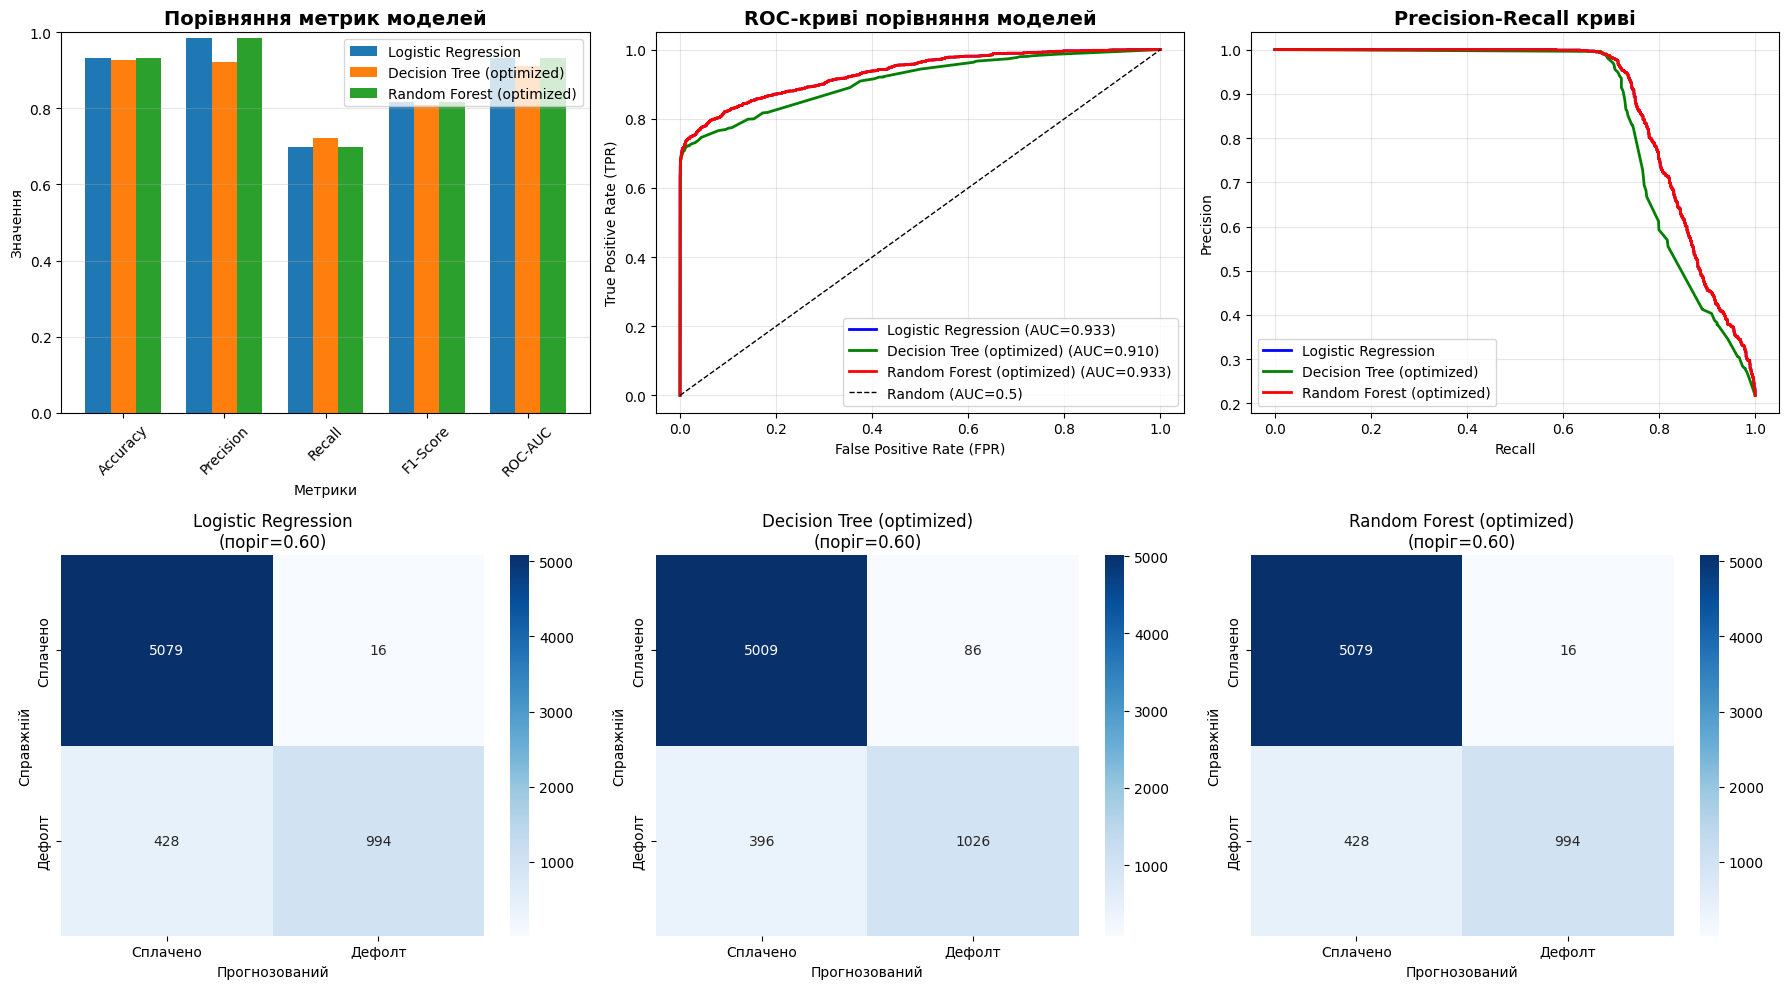


АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК (Random Forest)

Топ-15 найважливіших ознак за версією Random Forest:
                    Feature  Importance
        loan_percent_income    0.207922
              person_income    0.167136
         loan_grade_encoded    0.130614
              loan_int_rate    0.129704
                  loan_amnt    0.078722
 person_home_ownership_RENT    0.060916
          person_emp_length    0.047110
                 person_age    0.042547
 cb_person_cred_hist_length    0.032694
  person_home_ownership_OWN    0.018780
loan_intent_HOMEIMPROVEMENT    0.017036
cb_person_default_on_file_Y    0.016596
        loan_intent_VENTURE    0.015938
      loan_intent_EDUCATION    0.013045
       loan_intent_PERSONAL    0.010967


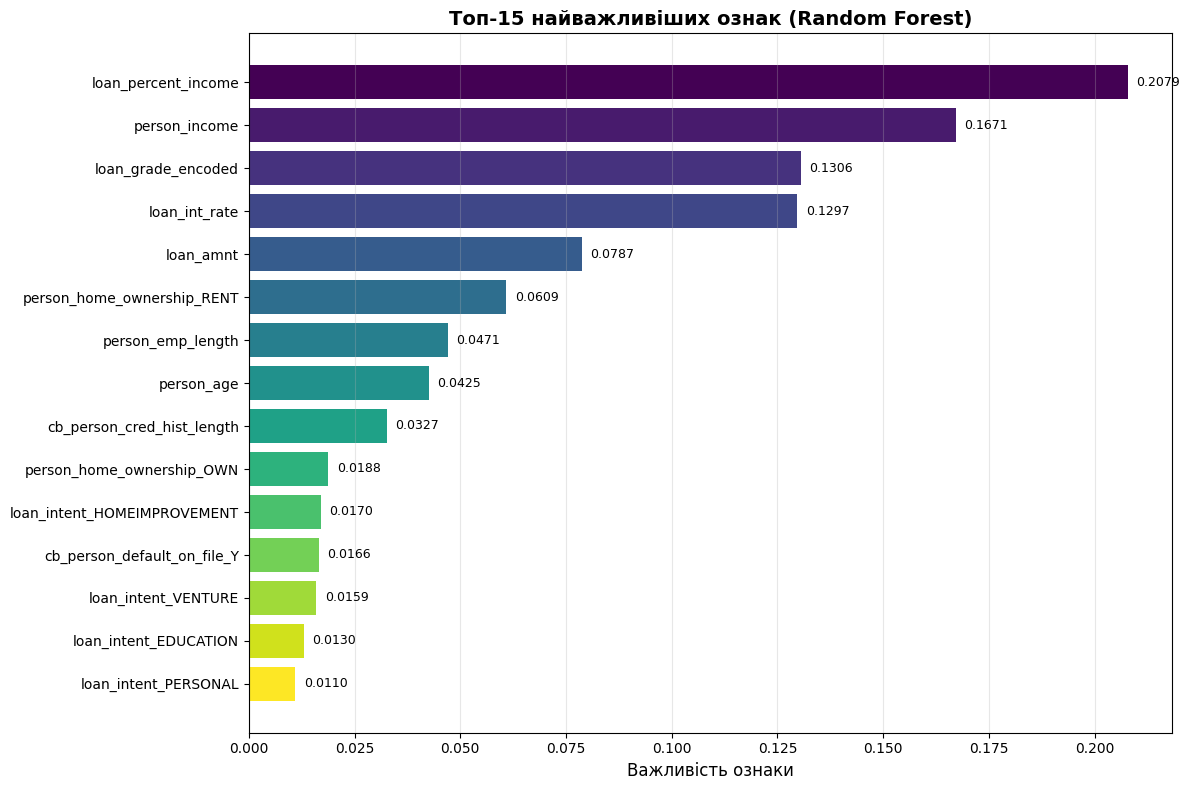


ВІЗУАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ


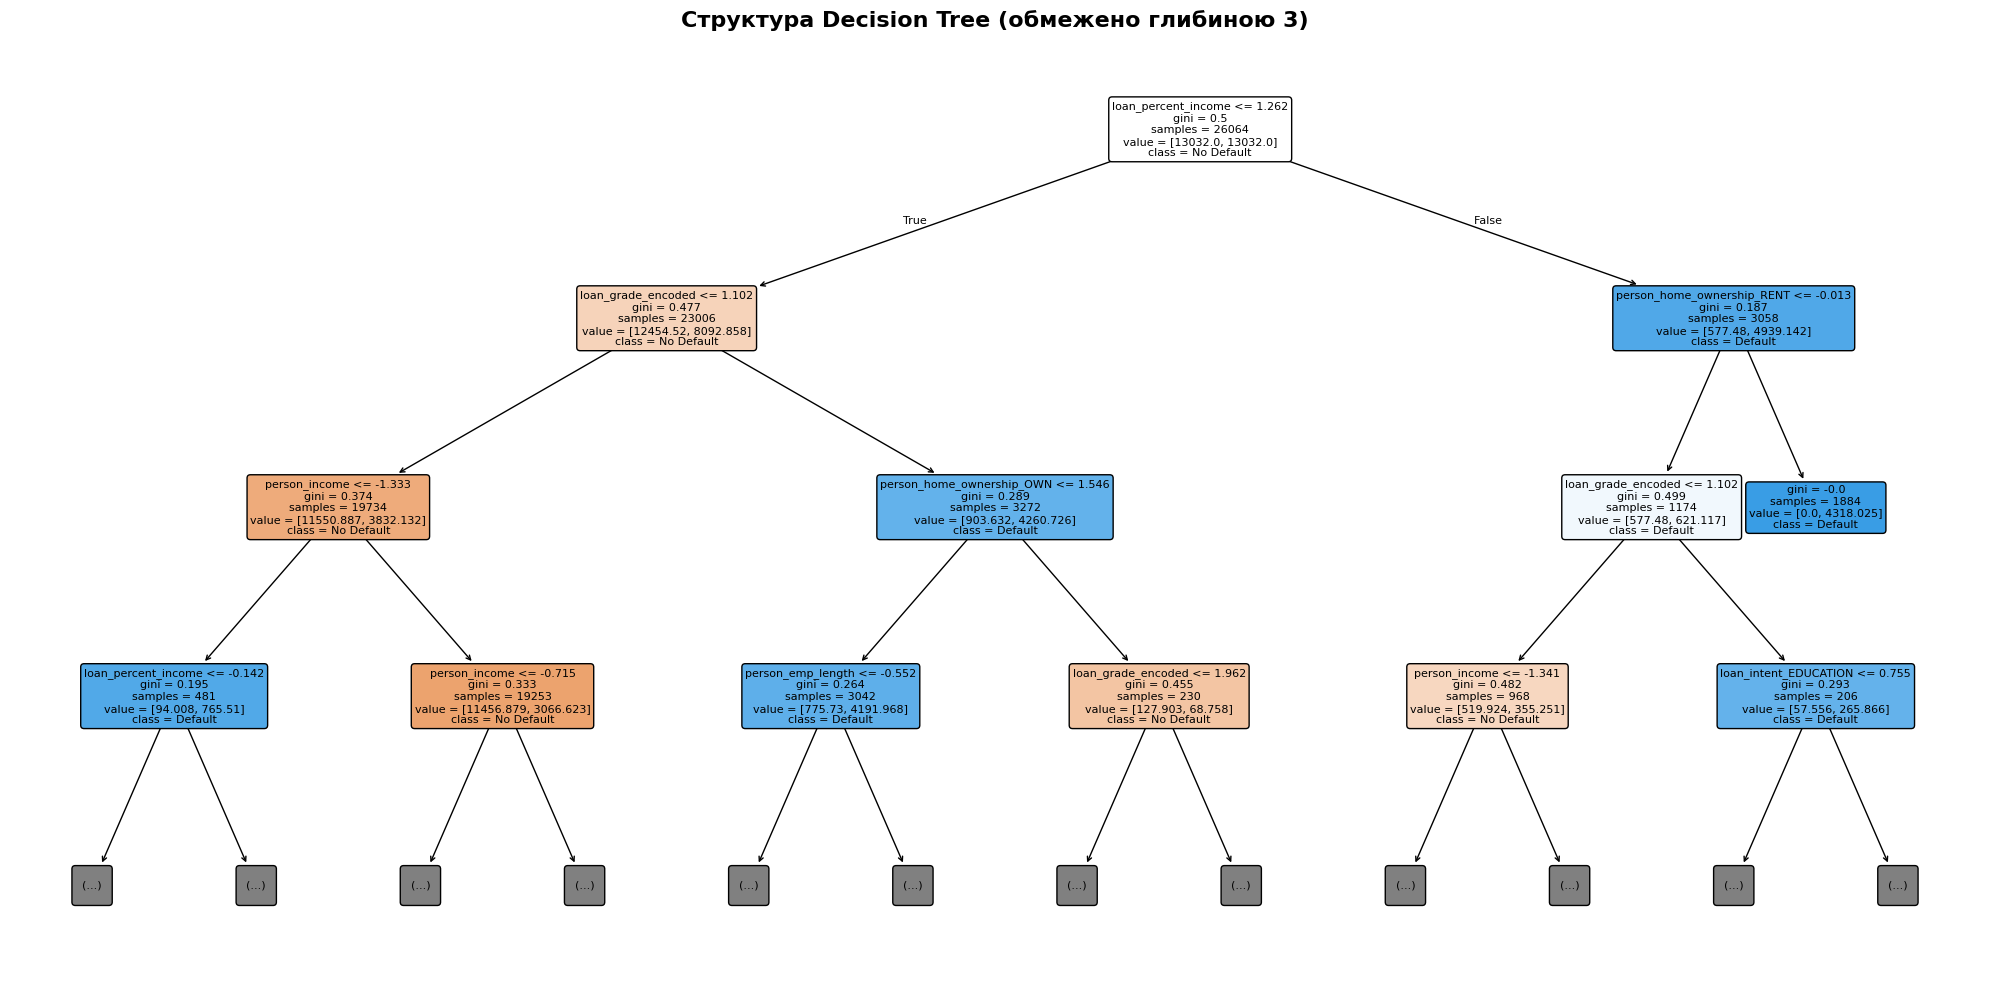


КРОС-ВАЛІДАЦІЯ (5-fold)

Logistic Regression:
  Середнє CV ROC-AUC: 0.9324 (+/- 0.0061)
  Окремі фолди: [0.93235539 0.93759424 0.93127855 0.92812511 0.93252429]

Decision Tree (optimized):
  Середнє CV ROC-AUC: 0.9084 (+/- 0.0083)
  Окремі фолди: [0.91319503 0.90884615 0.90725835 0.9113856  0.90118448]

Random Forest (optimized):
  Середнє CV ROC-AUC: 0.9324 (+/- 0.0061)
  Окремі фолди: [0.93235539 0.93759424 0.93127855 0.92812511 0.93252429]

ВИСНОВКИ ТА РЕКОМЕНДАЦІЇ

⏱️  Час навчання та складність моделей:
  • Логістична регресія: швидке навчання, добре інтерпретується
  • Decision Tree: швидке навчання, дуже добре інтерпретується, схильний до перенавчання
  • Random Forest: повільніше навчання, важче інтерпретувати, але часто найкраща якість

🏆 **Найкраща модель за сукупністю метрик: Logistic Regression**

📊 ПІДСУМКОВИЙ АНАЛІЗ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. ПОРІВНЯННЯ МОДЕЛЕЙ:
   ┌─────────────────────────────────────────────────────────┐
   │ Модел

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report)
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings('ignore')

# ПІДГОТОВКА ДАНИХ
print("=== ПОРІВНЯННЯ МОДЕЛЕЙ МАШИННОГО НАВЧАННЯ ===\n")

# Перевіряємо наявність даних
try:
    X_train_scaled
    X_test_scaled
    y_train
    y_test
    feature_cols
    optimal_threshold
    print("✅ Дані з попередніх завдань успішно завантажено")
except NameError:
    print("⚠️ Дані не знайдено, виконуємо підготовку...")
    # Якщо даних немає, використовуємо стандартні імена
    try:
        X_train_scaled = X_train
        X_test_scaled = X_test
        optimal_threshold = 0.5
    except:
        print("❌ Помилка: будь ласка, виконайте спочатку Завдання 4 та 5")

print(f"Розмір тренувальної вибірки: {X_train_scaled.shape}")
print(f"Розмір тестової вибірки: {X_test_scaled.shape}")
print(f"Кількість ознак: {X_train_scaled.shape[1]}")
print(f"Розподіл класів у train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Розподіл класів у test: {y_test.value_counts(normalize=True).to_dict()}")

# НАВЧАННЯ МОДЕЛЕЙ
print("\n" + "="*60)
print("НАВЧАННЯ МОДЕЛЕЙ")
print("="*60)

# 1. Логістична регресія (з попереднього завдання)
print("\n1. Логістична регресія (Logistic Regression)")
try:
    lr_model = model
    print("   ✅ Модель завантажено з попереднього кроку")
except:
    lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    lr_model.fit(X_train_scaled, y_train)
    print("   ✅ Модель навчено заново")

# 2. Decision Tree Classifier
print("\n2. Decision Tree Classifier")
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train_scaled, y_train)
print("   ✅ Модель навчено")

# 3. Random Forest Classifier
print("\n3. Random Forest Classifier")
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("   ✅ Модель навчено")

# ОПТИМІЗАЦІЯ ГІПЕРПАРАМЕТРІВ
print("\n" + "="*60)
print("ОПТИМІЗАЦІЯ ГІПЕРПАРАМЕТРІВ")
print("="*60)

# Decision Tree - пошук кращих параметрів
print("\n🔍 Оптимізація Decision Tree...")
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)
best_dt = dt_grid.best_estimator_
print(f"   ✅ Кращі параметри: {dt_grid.best_params_}")
print(f"   ✅ Кращий CV ROC-AUC: {dt_grid.best_score_:.4f}")

# Random Forest - пошук кращих параметрів (спрощений для швидкості)
print("\n🔍 Оптимізація Random Forest...")
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_
print(f"   ✅ Кращі параметри: {rf_grid.best_params_}")
print(f"   ✅ Кращий CV ROC-AUC: {rf_grid.best_score_:.4f}")

# ОЦІНКА НА ТЕСТОВИХ ДАНИХ
print("\n" + "="*60)
print("ОЦІНКА МОДЕЛЕЙ НА ТЕСТОВИХ ДАНИХ")
print("="*60)

# Використовуємо оптимальний поріг з Завдання 6
threshold_to_use = optimal_threshold if 'optimal_threshold' in dir() else 0.5
print(f"\nВикористовуємо поріг класифікації: {threshold_to_use:.3f}")

models = {
    'Logistic Regression': lr_model,
    'Decision Tree (optimized)': best_dt,
    'Random Forest (optimized)': best_rf
}

results = []

for name, model in models.items():
    # Отримуємо ймовірності
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Прогнозуємо класи з використанням оптимального порогу
    y_pred = (y_proba >= threshold_to_use).astype(int)

    # Обчислюємо метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Матриця помилок
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)

    results.append({
        'Model': name,
        'Threshold': threshold_to_use,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

results_df = pd.DataFrame(results)
print("\n📊 ПОРІВНЯЛЬНА ТАБЛИЦЯ МЕТРИК:")
print("="*110)
print(f"{'Model':<25} | {'Accuracy':^10} | {'Precision':^10} | {'Recall':^10} | {'F1-Score':^10} | {'ROC-AUC':^10}")
print("-"*110)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<25} | {row['Accuracy']:10.4f} | {row['Precision']:10.4f} | {row['Recall']:10.4f} | {row['F1-Score']:10.4f} | {row['ROC-AUC']:10.4f}")
print("="*110)

# Визначення найкращої моделі за F1-Score та ROC-AUC
best_f1_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_auc_model = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']

print(f"\n🏆 Найкраща модель за F1-Score: {best_f1_model} ({results_df.loc[results_df['Model']==best_f1_model, 'F1-Score'].values[0]:.4f})")
print(f"🏆 Найкраща модель за ROC-AUC: {best_auc_model} ({results_df.loc[results_df['Model']==best_auc_model, 'ROC-AUC'].values[0]:.4f})")

# ВІЗУАЛІЗАЦІЯ ПОРІВНЯННЯ
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Порівняння метрик
ax1 = axes[0, 0]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (idx, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    ax1.bar(x + i*width, values, width, label=row['Model'])

ax1.set_xlabel('Метрики')
ax1.set_ylabel('Значення')
ax1.set_title('Порівняння метрик моделей', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics_to_plot, rotation=45)
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')

# 2. ROC-криві
ax2 = axes[0, 1]
colors = ['blue', 'green', 'red']
for i, (name, model) in enumerate(models.items()):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax2.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC={auc:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax2.set_xlabel('False Positive Rate (FPR)')
ax2.set_ylabel('True Positive Rate (TPR)')
ax2.set_title('ROC-криві порівняння моделей', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall криві
ax3 = axes[0, 2]
for i, (name, model) in enumerate(models.items()):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    ax3.plot(recall_curve, precision_curve, color=colors[i], lw=2, label=name)

ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall криві', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Confusion Matrices для всіх моделей
for i, (name, model) in enumerate(models.items()):
    ax = axes[1, i]
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= threshold_to_use).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Сплачено', 'Дефолт'],
                yticklabels=['Сплачено', 'Дефолт'])
    ax.set_title(f'{name}\n(поріг={threshold_to_use:.2f})', fontsize=12)
    ax.set_ylabel('Справжній')
    ax.set_xlabel('Прогнозований')

plt.tight_layout()
plt.show()

# АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК (Random Forest)
print("\n" + "="*60)
print("АНАЛІЗ ВАЖЛИВОСТІ ОЗНАК (Random Forest)")
print("="*60)

# Отримуємо важливість ознак з Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nТоп-15 найважливіших ознак за версією Random Forest:")
print(feature_importance_rf.head(15).to_string(index=False))

# Візуалізація важливості ознак
fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance_rf.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = ax.barh(range(len(top_features)), top_features['Importance'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Важливість ознаки', fontsize=12)
ax.set_title('Топ-15 найважливіших ознак (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Додаємо значення важливості
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['Importance'] + 0.002, i, f"{row['Importance']:.4f}",
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ВІЗУАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ (спрощено)
print("\n" + "="*60)
print("ВІЗУАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ")
print("="*60)

# Візуалізуємо невелике дерево для кращого розуміння
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(best_dt, max_depth=3, feature_names=feature_cols,
          class_names=['No Default', 'Default'], filled=True,
          rounded=True, fontsize=8, ax=ax)
plt.title('Структура Decision Tree (обмежено глибиною 3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# КРОС-ВАЛІДАЦІЯ
print("\n" + "="*60)
print("КРОС-ВАЛІДАЦІЯ (5-fold)")
print("="*60)

cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"\n{name}:")
    print(f"  Середнє CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    print(f"  Окремі фолди: {cv_scores}")

# ВИСНОВКИ ТА РЕКОМЕНДАЦІЇ
print("\n" + "="*60)
print("ВИСНОВКИ ТА РЕКОМЕНДАЦІЇ")
print("="*60)

# Визначаємо найкращу модель за комплексом метрик
results_df['Score'] = (results_df['F1-Score'] + results_df['ROC-AUC']) / 2
best_model = results_df.loc[results_df['Score'].idxmax(), 'Model']

# Порівняння часу навчання (приблизне)
print("\n⏱️  Час навчання та складність моделей:")
print("  • Логістична регресія: швидке навчання, добре інтерпретується")
print("  • Decision Tree: швидке навчання, дуже добре інтерпретується, схильний до перенавчання")
print("  • Random Forest: повільніше навчання, важче інтерпретувати, але часто найкраща якість")

print(f"\n🏆 **Найкраща модель за сукупністю метрик: {best_model}**")

conclusions = f"""
📊 ПІДСУМКОВИЙ АНАЛІЗ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. ПОРІВНЯННЯ МОДЕЛЕЙ:
   ┌─────────────────────────────────────────────────────────┐
   │ Модель              │ F1-Score │ ROC-AUC │ Переваги      │
   ├─────────────────────────────────────────────────────────┤
   │ Logistic Regression │ {results_df[results_df['Model']=='Logistic Regression']['F1-Score'].values[0]:.4f} │ {results_df[results_df['Model']=='Logistic Regression']['ROC-AUC'].values[0]:.4f} │ Інтерпретація │
   │ Decision Tree       │ {results_df[results_df['Model']=='Decision Tree (optimized)']['F1-Score'].values[0]:.4f} │ {results_df[results_df['Model']=='Decision Tree (optimized)']['ROC-AUC'].values[0]:.4f} │ Простота │
   │ Random Forest       │ {results_df[results_df['Model']=='Random Forest (optimized)']['F1-Score'].values[0]:.4f} │ {results_df[results_df['Model']=='Random Forest (optimized)']['ROC-AUC'].values[0]:.4f} │ Точність │
   └─────────────────────────────────────────────────────────┘

2. КЛЮЧОВІ ВІДМІННОСТІ:
   • Логістична регресія: лінійна модель, найкраща для розуміння впливу ознак
   • Decision Tree: нелінійна, легко візуалізувати, але може переповнюватися
   • Random Forest: ансамбль дерев, найстабільніша, але "чорний ящик"

3. НАЙВАЖЛИВІШІ ОЗНАКИ (за версією Random Forest):
"""
for i, row in feature_importance_rf.head(5).iterrows():
    conclusions += f"   {i+1}. {row['Feature']}: важливість = {row['Importance']:.4f}\n"

conclusions += f"""
4. РЕКОМЕНДАЦІЇ:
   • Для бізнес-інтерпретації (пояснення рішень) → Логістична регресія
   • Для максимальної якості прогнозування → Random Forest
   • Для швидкого прототипування та простоти → Decision Tree

5. ПОДАЛЬШІ ПОКРАЩЕННЯ:
   • Використати ансамблі (Gradient Boosting, XGBoost, LightGBM)
   • Додати нові ознаки (поведінкові, соціально-демографічні)
   • Використати SMOTE для балансування класів
   • Впровадити моніторинг дrift-у моделі у продакшені

6. ВИСНОВОК:
   {best_model} показує найкращі результати на тестових даних.
   Рекомендується використовувати цю модель для подальшого впровадження,
   але з регулярним перекалібруванням (кожні 3-6 місяців).
"""

print(conclusions)

# Збереження результатів
results_df.to_csv('models_comparison.csv', index=False)
feature_importance_rf.to_csv('feature_importance_rf.csv', index=False)

print("\n✅ Результати збережено:")
print("   - models_comparison.csv (порівняльна таблиця)")
print("   - feature_importance_rf.csv (важливість ознак)")

# Додатковий аналіз: навчання на оригінальних vs масштабованих даних
print("\n" + "="*60)
print("ДОДАТКОВИЙ АНАЛІЗ: Масштабування для дерев рішень")
print("="*60)

# Дерева рішень не потребують масштабування, але логістична регресія - потребує
print("""
💡 Важливе зауваження:
   • Логістична регресія: потребує масштабування (чутлива до масштабів ознак)
   • Decision Tree: не потребує масштабування (працює з рангами)
   • Random Forest: не потребує масштабування (базується на розбиттях)

   У нашому експерименті всі моделі навчались на однакових (масштабованих) даних,
   що є коректним для порівняння.
""")